# **LBLDE and DP-LLDE Testing Notebook**
**Level-Based Learning Differential Evolution — Google Colab**

**Diversity-Preserving Level-Guided Learning Differential Evolution - Google Colab**

This notebook tests the LBLDE algorithm on classical benchmark functions and CEC 2017 functions.

---
# **1. LBLDE**

---



## **1.1. Setup and Installation**


---



Install `opfunu` to import CEC 2017 Benchmark Functions

In [ ]:
!pip install opfunu numpy scipy --quiet
print("All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 15.2 MB/s eta 0:00:00
All packages installed successfully!


Import `files` and `os` for uploading a file to the environment's file system

In [ ]:
from google.colab import files
import os

View if `lblde.py` is already uploaded or not. If no, then request attachment upload

In [ ]:
if not os.path.exists('lblde.py'):
    print("Please upload lblde.py when the dialog appears...")
    uploaded = files.upload()
    if 'lblde.py' in uploaded:
        print("lblde.py uploaded successfully!")
    else:
        print("lblde.py was not found in the upload. Please try again.")
else:
    print("lblde.py already present in the session.")

lblde.py already present in the session.


Import `np`, `sys`, and `warnings` system-level operations, and control over warning messages

In [ ]:
import numpy as np
import sys
import warnings

This code suppresses warning messages and ensures the current directory is included in Python’s system path so that `lblde.py`can be imported.


> Imports `run_multiple_trials`



In [ ]:
warnings.filterwarnings('ignore')

# Add current directory to path so lblde.py is importable
if '.' not in sys.path:
    sys.path.insert(0, '.')

try:
    from lblde import LBLDE, run_multiple_trials
    print("LBLDE imported successfully!")
except ImportError as e:
    print(f"Import failed: {e}")
    print("  Make sure lblde.py is uploaded and in the current directory.")

LBLDE imported successfully!



## **1.2. Test 1 — Basic Benchmark Functions**


---



Define 3 basic benchmark functions for testing

In [ ]:
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    n = len(x)
    return 10*n + np.sum(x**2 - 10*np.cos(2*np.pi*x))

def rosenbrock(x):
    return np.sum(100*(x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

print("Benchmark functions defined.")

Benchmark functions defined.


Tests LBLDE on three classical functions: **Sphere**, **Rastrigin**, and **Rosenbrock**.

In [ ]:
print("="*80)
print("Testing LBLDE on Basic Benchmark Functions")
print("="*80)

D = 10
tests = [
    ("Sphere",     sphere,     [-100,   100]),
    ("Rastrigin",  rastrigin,  [-5.12, 5.12]),
    ("Rosenbrock", rosenbrock, [-30,    30]),
]

for name, func, bound_range in tests:
    print(f"\n{'-'*80}")
    print(f"Function: {name} ({D}D)")
    print(f"{'-'*80}")

    bounds = np.array([bound_range] * D)

    optimizer = LBLDE(
        objective_func=func,
        bounds=bounds,
        NP=100,
        NL=4,
        NLB=1,
        mu_CR_ini=0.35,
        max_fes=10000 * D,
        seed=42
    )

    best_sol, best_fit, history = optimizer.optimize(verbose=False)

    print(f"  Best Fitness   : {best_fit:.6e}")
    print(f"  Generations    : {len(history)}")

print("\n" + "="*80)
print("Basic tests completed!")
print("="*80)

Testing LBLDE on Basic Benchmark Functions

--------------------------------------------------------------------------------
Function: Sphere (10D)
--------------------------------------------------------------------------------
  Best Fitness   : 4.822855e-90
  Generations    : 1000

--------------------------------------------------------------------------------
Function: Rastrigin (10D)
--------------------------------------------------------------------------------
  Best Fitness   : 0.000000e+00
  Generations    : 1000

--------------------------------------------------------------------------------
Function: Rosenbrock (10D)
--------------------------------------------------------------------------------
  Best Fitness   : 0.000000e+00
  Generations    : 1000

Basic tests completed!


## **1.3. Test 2 — Single CEC 2017 Function (F1)**


---



Run a single optimisation trial on **F1** (Shifted and Rotated Bent Cigar) and reports the error against the known global optimum.

In [ ]:
print("="*80)
print("Testing LBLDE on CEC 2017 F1")
print("="*80)

try:
    from opfunu.cec_based import cec2017
    print("opfunu CEC 2017 library loaded")
except ImportError:
    raise SystemExit("opfunu not found. Re-run the installation cell at the top.")

D = 10
print(f"\nFunction : F1 — Shifted and Rotated Bent Cigar ({D}D)")

func_obj = cec2017.F12017(ndim=D)
print(f"Bounds         : {func_obj.bounds[0]}")
print(f"Global optimum : {func_obj.f_global}")

print("\nRunning LBLDE...")
optimizer = LBLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100,
    NL=4,
    NLB=1,
    mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = optimizer.optimize(verbose=True)

error = best_fit - func_obj.f_global

print(f"\n{'='*80}")
print("Results:")
print(f"  Best Fitness   : {best_fit:.6e}")
print(f"  Global Optimum : {func_obj.f_global:.6e}")
print(f"  Error          : {error:.6e}")
print(f"  Best Solution (first 5 dims): {best_sol[:5]}")
print(f"{'='*80}")

Testing LBLDE on CEC 2017 F1
opfunu CEC 2017 library loaded

Function : F1 — Shifted and Rotated Bent Cigar (10D)
Bounds         : [-100.  100.]
Global optimum : 100.0

Running LBLDE...
Generation 0: Best Fitness = 1.871674e+10
Generation 10: Best Fitness = 1.334429e+09, FES = 1100
Generation 20: Best Fitness = 1.429221e+08, FES = 2100
Generation 30: Best Fitness = 2.881740e+07, FES = 3100
Generation 40: Best Fitness = 5.067489e+06, FES = 4100
Generation 50: Best Fitness = 8.460063e+05, FES = 5100
Generation 60: Best Fitness = 2.279326e+05, FES = 6100
Generation 70: Best Fitness = 7.909739e+04, FES = 7100
Generation 80: Best Fitness = 3.898910e+04, FES = 8100
Generation 90: Best Fitness = 7.023667e+03, FES = 9100
Generation 100: Best Fitness = 3.360094e+03, FES = 10100
Generation 110: Best Fitness = 8.619206e+02, FES = 11100
Generation 120: Best Fitness = 5.383522e+02, FES = 12100
Generation 130: Best Fitness = 2.395506e+02, FES = 13100
Generation 140: Best Fitness = 1.318351e+02, FES 

## **1.4. Test 3 — Multiple Runs on CEC 2017 F1 (51 runs)**


---




Replicates the paper's protocol: **51 independent runs** on F1 (Shifted and Rotated Bent Cigar) and reports mean / std / median / min / max error.

In [ ]:
print("="*80)
print("Multiple Runs Test (51 runs as in paper)")
print("="*80)

try:
    from opfunu.cec_based import cec2017
except ImportError:
    raise SystemExit("opfunu not found. Re-run the installation cell at the top.")

D      = 10
n_runs = 51   # As specified in the paper

print(f"\nFunction : F1 ({D}D)")
print(f"Runs     : {n_runs}")
print(f"Max FES  : {10000 * D}")

func_obj = cec2017.F12017(ndim=D)

print("\nRunning trials (this may take a few minutes)...")
results = run_multiple_trials(
    func=func_obj.evaluate,
    bounds=func_obj.bounds,
    D=D,
    n_runs=n_runs,
    max_fes=10000 * D,
    verbose=False
)

errors = results['all_best'] - func_obj.f_global

print(f"\n{'='*80}")
print("Statistical Results (Error = f(x*) − f_global):")
print(f"  Mean   : {np.mean(errors):.6e}")
print(f"  Std    : {np.std(errors):.6e}")
print(f"  Median : {np.median(errors):.6e}")
print(f"  Min    : {np.min(errors):.6e}")
print(f"  Max    : {np.max(errors):.6e}")
print(f"\n  Paper reference (F1, 10D): 0.00e+00 ± 0.00e+00")
print(f"{'='*80}")

## **1.5. Test 4 — Multiple CEC 2017 Functions (F1–F5)**

---




Run a single trial on **F1 - F5** and prints a summary error table.

In [ ]:
print("="*80)
print("Testing Multiple CEC 2017 Functions (F1–F5)")
print("="*80)

try:
    from opfunu.cec_based import cec2017
except ImportError:
    raise SystemExit("opfunu not found. Re-run the installation cell at the top.")

D = 10

functions = [
    (1, cec2017.F12017,  "Shifted and Rotated Bent Cigar"),
    (2, cec2017.F22017,  "Shifted and Rotated Sum of Different Power"),
    (3, cec2017.F32017,  "Shifted and Rotated Zakharov"),
    (4, cec2017.F42017,  "Shifted and Rotated Rosenbrock's"),
    (5, cec2017.F52017,  "Shifted and Rotated Rastrigin's"),
]

results_list = []

for func_num, FuncClass, func_name in functions:
    print(f"\n{'-'*80}")
    print(f"F{func_num}: {func_name} ({D}D)")
    print(f"{'-'*80}")

    func_obj = FuncClass(ndim=D)

    optimizer = LBLDE(
        objective_func=func_obj.evaluate,
        bounds=func_obj.bounds,
        NP=100,
        NL=4,
        NLB=1,
        mu_CR_ini=0.35,
        max_fes=10000 * D,
        seed=42
    )

    best_sol, best_fit, history = optimizer.optimize(verbose=False)
    error = best_fit - func_obj.f_global

    print(f"  Best Fitness : {best_fit:.6e}")
    print(f"  Error        : {error:.6e}")

    results_list.append({
        'Function': f'F{func_num}',
        'Name': func_name,
        'Best_Fitness': best_fit,
        'Error': error
    })

print(f"\n{'='*80}")
print("Summary of Results:")
print(f"{'='*80}")
print(f"{'Func':<6}  {'Error':>14}  Name")
print("-"*80)
for r in results_list:
    print(f"{r['Function']:<6}  {r['Error']:>14.6e}  {r['Name']}")
print(f"{'='*80}")

---
## Next Steps

- **Test all 30 CEC 2017 functions** — extend the `functions` list in Test 4 with `F62017` through `F302017`.
- **Higher dimensions** — change `D` to `30`, `50`, or `100` in any test cell.
- **Full paper experiment** — set `n_runs = 51` and loop over all 30 functions in Test 3's pattern.
- **Convergence plots** — use `matplotlib` on the `history` list returned by `optimizer.optimize()`.



---


# **2. DP-LLDE**

---



## **2.1. Setup and Installation**


---



Install `opfunu` to import CEC 2017 Benchmark Functions

In [ ]:
!pip install opfunu numpy scipy --quiet
print("All packages installed successfully!")

All packages installed successfully!


Import `files` and `os` for uploading a file to the environment's file system

In [ ]:
from google.colab import files
import os

View if `dpllde.py` is already uploaded or not. If no, then request attachment upload.

In [ ]:
for fname in ['dpllde.py']:
    if not os.path.exists(fname):
        print(f'Please upload {fname} when the dialog appears...')
        uploaded = files.upload()
        if fname in uploaded:
            print(f'{fname} uploaded.')
        else:
            print(f'{fname} not found in upload — please retry.')
    else:
        print(f'{fname} already present.')

dpllde.py already present.


Import `np`, `plt`, `sys`, and `warnings` system-level operations, and control over warning messages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys, warnings

This code suppresses warning messages and ensures the current directory is included in Python’s system path so that `dpllde.py`can be imported.


> Imports `run_multiple_trials`, and other basic functions



In [ ]:
warnings.filterwarnings('ignore')

if '.' not in sys.path:
    sys.path.insert(0, '.')

try:
    from dpllde import DPLLDE, run_multiple_trials
    from dpllde import sphere, rastrigin, rosenbrock, ackley, griewank
    print('DPLLDE imported successfully!')
except ImportError as e:
    print(f'Import failed: {e}')
    print('  Make sure dpllde.py is uploaded and in the current directory.')

DPLLDE imported successfully!



## **2.2. Test 1 — Basic Benchmark Functions**


---



Tests DP-LLDE on five classical functions: **Sphere**, **Rastrigin**, **Rosenbrock**, **Ackley**, and **Griewank**.

In [ ]:
print('=' * 80)
print('DP-LLDE on Classical Benchmark Functions (10-D, single run)')
print('=' * 80)

D = 10
tests = [
    ('Sphere',     sphere,     [-100,   100],  0.0),
    ('Rastrigin',  rastrigin,  [-5.12, 5.12],  0.0),
    ('Rosenbrock', rosenbrock, [-30,    30],    0.0),
    ('Ackley',     ackley,     [-32,    32],    0.0),
    ('Griewank',   griewank,   [-600,   600],   0.0),
]

for name, func, bound_range, optimum in tests:
    bounds = np.array([bound_range] * D)
    opt = DPLLDE(
        objective_func=func, bounds=bounds,
        NP=100, NL=4, mu_CR_ini=0.35,
        max_fes=10000 * D, seed=42
    )
    _, best_fit, _ = opt.optimize(verbose=False)
    error = best_fit - optimum
    print(f'  {name:<12}: Best = {best_fit:.6e}  |  Error = {error:.6e}')

print('\nBasic tests completed!')

DP-LLDE on Classical Benchmark Functions (10-D, single run)
  Sphere      : Best = 9.640587e-118  |  Error = 9.640587e-118
  Rastrigin   : Best = 0.000000e+00  |  Error = 0.000000e+00
  Rosenbrock  : Best = 1.495469e-01  |  Error = 1.495469e-01
  Ackley      : Best = 3.996803e-15  |  Error = 3.996803e-15
  Griewank    : Best = 0.000000e+00  |  Error = 0.000000e+00

Basic tests completed!


Plot the best-fitness convergence

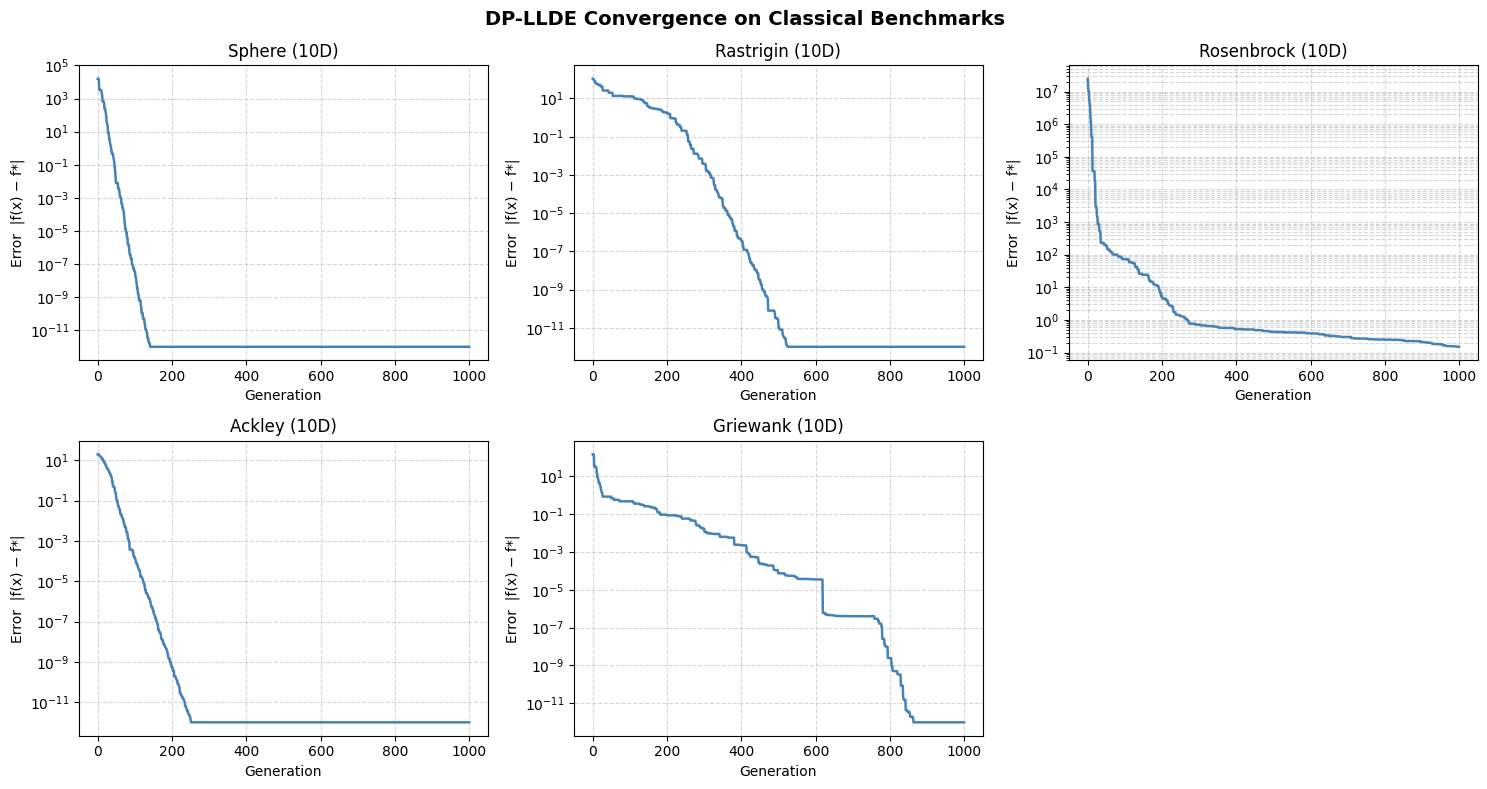

Convergence plot saved to convergence_classical.png


In [ ]:
D = 10
plot_tests = [
    ('Sphere',     sphere,     [-100,   100],  0.0),
    ('Rastrigin',  rastrigin,  [-5.12, 5.12],  0.0),
    ('Rosenbrock', rosenbrock, [-30,    30],    0.0),
    ('Ackley',     ackley,     [-32,    32],    0.0),
    ('Griewank',   griewank,   [-600,   600],   0.0),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (name, func, bound_range, optimum) in zip(axes, plot_tests):
    bounds = np.array([bound_range] * D)
    opt = DPLLDE(
        objective_func=func, bounds=bounds,
        NP=100, NL=4, mu_CR_ini=0.35,
        max_fes=10000 * D, seed=42
    )
    _, _, history = opt.optimize(verbose=False)
    errors = [max(h - optimum, 1e-12) for h in history]

    ax.semilogy(errors, linewidth=1.8, color='steelblue')
    ax.set_title(f'{name} ({D}D)', fontsize=12)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Error  |f(x) − f*|')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('DP-LLDE Convergence on Classical Benchmarks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_classical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Convergence plot saved to convergence_classical.png')


## **2.3. Test 2 — Single CEC 2017 Function**


---



Import `matplotlib` for graph visualization

In [ ]:
import matplotlib.pyplot as plt

### **2.3.1. Unimodal Functions (F1-F3)**

---



### **F1**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F1 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F12017(ndim=D)
print(f'\nFunction       : F1 — Shifted and Rotated Bent Cigar ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F1 — Single Run
opfunu CEC 2017 loaded!

Function       : F1 — Shifted and Rotated Bent Cigar (10D)
Bounds         : [-100.  100.]
Global optimum : 100.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.871674e+10
Generation   10: Best = 2.358232e+09  FES =   1100  μ_F = 0.595  μ_CR = 0.353
Generation   20: Best = 2.836413e+08  FES =   2100  μ_F = 0.648  μ_CR = 0.360
Generation   30: Best = 1.320020e+08  FES =   3100  μ_F = 0.682  μ_CR = 0.371
Generation   40: Best = 4.067723e+07  FES =   4100  μ_F = 0.694  μ_CR = 0.367
Generation   50: Best = 1.425244e+07  FES =   5100  μ_F = 0.719  μ_CR = 0.366
Generation   60: Best = 1.425244e+07  FES =   6100  μ_F = 0.707  μ_CR = 0.348
Generation   70: Best = 6.730095e+06  FES =   7100  μ_F = 0.732  μ_CR = 0.340
Generation   80: Best = 1.588525e+06  FES =   8100  μ_F = 0.743  μ_CR = 0.329
Generation   90: Best = 1.060394e+06  FES =   9100  μ_F = 0.754  μ_CR = 0.331
Generation  100: B

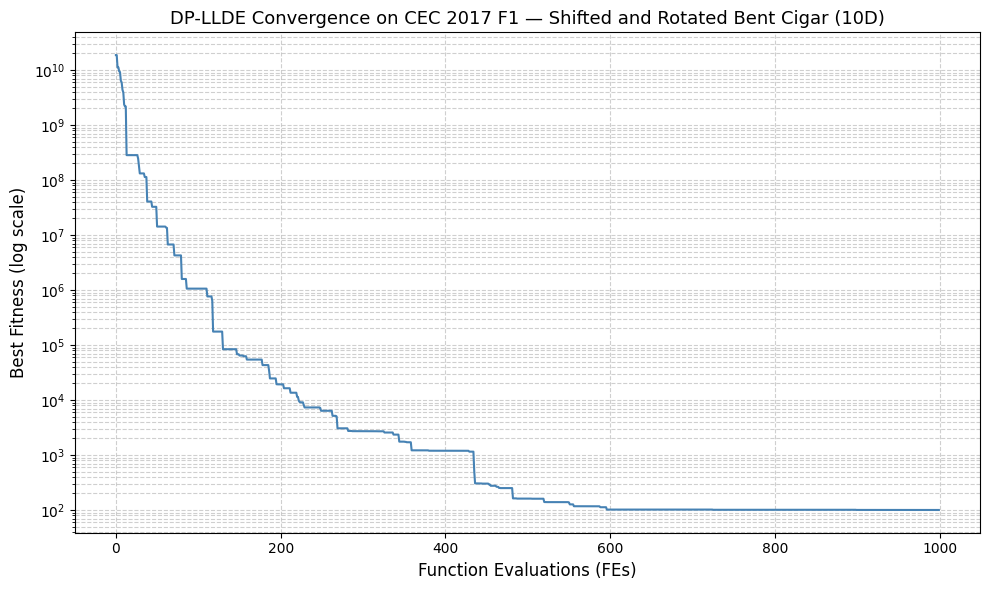

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F1 — Shifted and Rotated Bent Cigar (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F1.png', dpi=150)
plt.show()

### **F2**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F2 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F22017(ndim=D)
print(f'\nFunction       : F2 — Shifted and Rotated Sum of Different Power ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F2 — Single Run
opfunu CEC 2017 loaded!

Function       : F2 — Shifted and Rotated Sum of Different Power (10D)
Bounds         : [-100.  100.]
Global optimum : 200.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 5.111516e+04
Generation   10: Best = 4.433936e+03  FES =   1100  μ_F = 0.572  μ_CR = 0.356
Generation   20: Best = 4.433936e+03  FES =   2100  μ_F = 0.625  μ_CR = 0.365
Generation   30: Best = 3.251757e+03  FES =   3100  μ_F = 0.643  μ_CR = 0.383
Generation   40: Best = 3.251757e+03  FES =   4100  μ_F = 0.688  μ_CR = 0.350
Generation   50: Best = 3.251757e+03  FES =   5100  μ_F = 0.724  μ_CR = 0.348
Generation   60: Best = 2.029063e+03  FES =   6100  μ_F = 0.733  μ_CR = 0.373
Generation   70: Best = 1.650355e+03  FES =   7100  μ_F = 0.754  μ_CR = 0.374
Generation   80: Best = 1.336414e+03  FES =   8100  μ_F = 0.755  μ_CR = 0.404
Generation   90: Best = 9.095853e+02  FES =   9100  μ_F = 0.768  μ_CR = 0.411
Genera

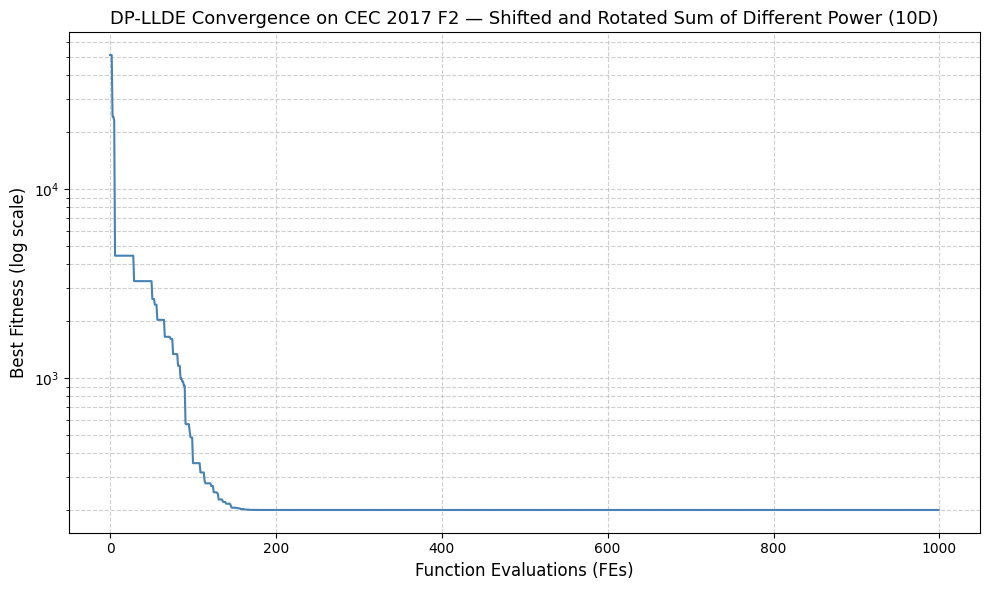

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F2 — Shifted and Rotated Sum of Different Power (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F2.png', dpi=150)
plt.show()

### **F3**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F3 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F32017(ndim=D)
print(f'\nFunction       : F3 — Shifted and Rotated Zakharov ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F3 — Single Run
opfunu CEC 2017 loaded!

Function       : F3 — Shifted and Rotated Zakharov (10D)
Bounds         : [-100.  100.]
Global optimum : 300.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.320888e+03
Generation   10: Best = 4.953415e+02  FES =   1100  μ_F = 0.595  μ_CR = 0.352
Generation   20: Best = 3.944539e+02  FES =   2100  μ_F = 0.642  μ_CR = 0.360
Generation   30: Best = 3.340072e+02  FES =   3100  μ_F = 0.678  μ_CR = 0.367
Generation   40: Best = 3.196754e+02  FES =   4100  μ_F = 0.731  μ_CR = 0.361
Generation   50: Best = 3.170744e+02  FES =   5100  μ_F = 0.751  μ_CR = 0.357
Generation   60: Best = 3.119085e+02  FES =   6100  μ_F = 0.763  μ_CR = 0.342
Generation   70: Best = 3.092956e+02  FES =   7100  μ_F = 0.759  μ_CR = 0.316
Generation   80: Best = 3.079898e+02  FES =   8100  μ_F = 0.765  μ_CR = 0.316
Generation   90: Best = 3.060239e+02  FES =   9100  μ_F = 0.786  μ_CR = 0.322
Generation  100: Bes

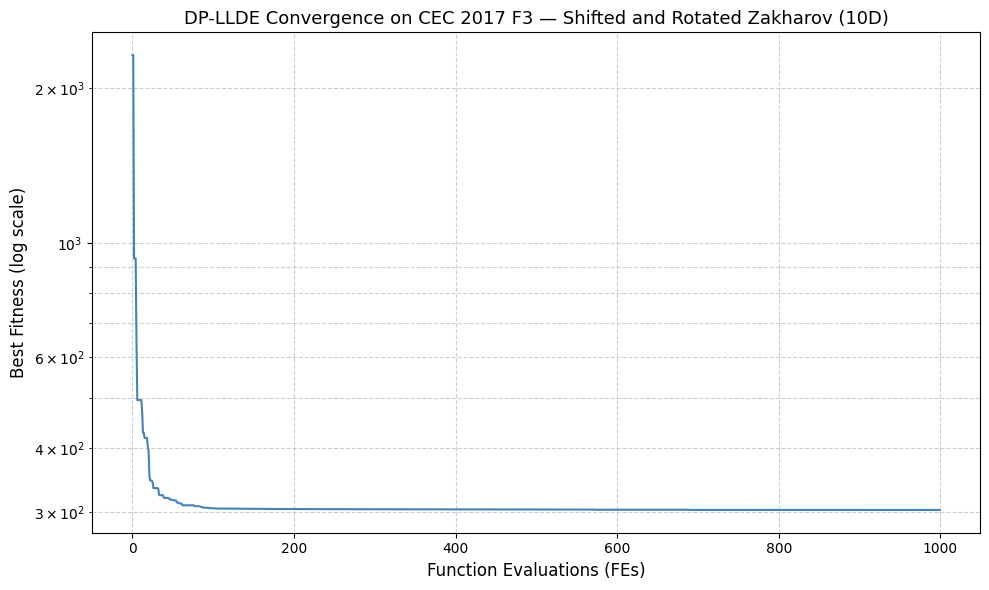

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F3 — Shifted and Rotated Zakharov (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F3.png', dpi=150)
plt.show()

### **2.3.2. Multimodal Functions (F4-F10)**

---



### **F4**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F4 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F42017(ndim=D)
print(f'\nFunction       : F4 — Shifted and Rotated Rosenbrock ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F4 — Single Run
opfunu CEC 2017 loaded!

Function       : F4 — Shifted and Rotated Rosenbrock (10D)
Bounds         : [-100.  100.]
Global optimum : 400.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.157492e+04
Generation   10: Best = 3.293225e+03  FES =   1100  μ_F = 0.581  μ_CR = 0.355
Generation   20: Best = 1.154191e+03  FES =   2100  μ_F = 0.639  μ_CR = 0.363
Generation   30: Best = 5.437429e+02  FES =   3100  μ_F = 0.685  μ_CR = 0.367
Generation   40: Best = 4.645955e+02  FES =   4100  μ_F = 0.722  μ_CR = 0.363
Generation   50: Best = 4.633332e+02  FES =   5100  μ_F = 0.747  μ_CR = 0.352
Generation   60: Best = 4.428471e+02  FES =   6100  μ_F = 0.776  μ_CR = 0.328
Generation   70: Best = 4.428471e+02  FES =   7100  μ_F = 0.770  μ_CR = 0.300
Generation   80: Best = 4.403861e+02  FES =   8100  μ_F = 0.764  μ_CR = 0.257
Generation   90: Best = 4.294523e+02  FES =   9100  μ_F = 0.763  μ_CR = 0.210
Generation  100: B

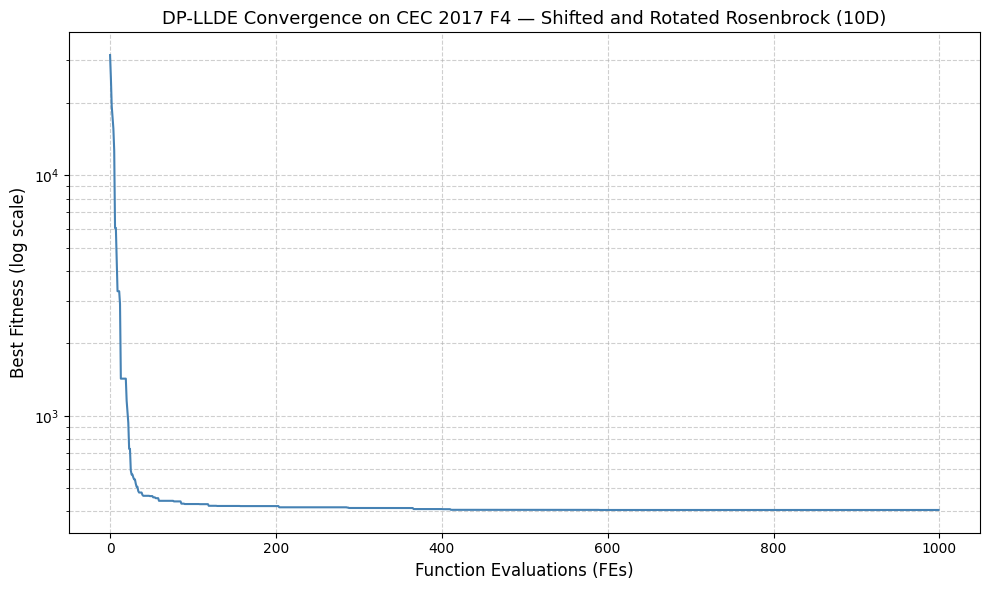

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F4 — Shifted and Rotated Rosenbrock (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F4.png', dpi=150)
plt.show()

### **F5**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F5 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F52017(ndim=D)
print(f'\nFunction       : F5 — Shifted and Rotated Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F5 — Single Run
opfunu CEC 2017 loaded!

Function       : F5 — Shifted and Rotated Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 500.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 5.000201e+02
Generation   10: Best = 5.000057e+02  FES =   1100  μ_F = 0.559  μ_CR = 0.347
Generation   20: Best = 5.000039e+02  FES =   2100  μ_F = 0.648  μ_CR = 0.349
Generation   30: Best = 5.000019e+02  FES =   3100  μ_F = 0.661  μ_CR = 0.339
Generation   40: Best = 5.000010e+02  FES =   4100  μ_F = 0.687  μ_CR = 0.311
Generation   50: Best = 5.000006e+02  FES =   5100  μ_F = 0.708  μ_CR = 0.274
Generation   60: Best = 5.000002e+02  FES =   6100  μ_F = 0.754  μ_CR = 0.256
Generation   70: Best = 5.000002e+02  FES =   7100  μ_F = 0.803  μ_CR = 0.225
Generation   80: Best = 5.000002e+02  FES =   8100  μ_F = 0.801  μ_CR = 0.185
Generation   90: Best = 5.000002e+02  FES =   9100  μ_F = 0.823  μ_CR = 0.145
Generation  100: Be

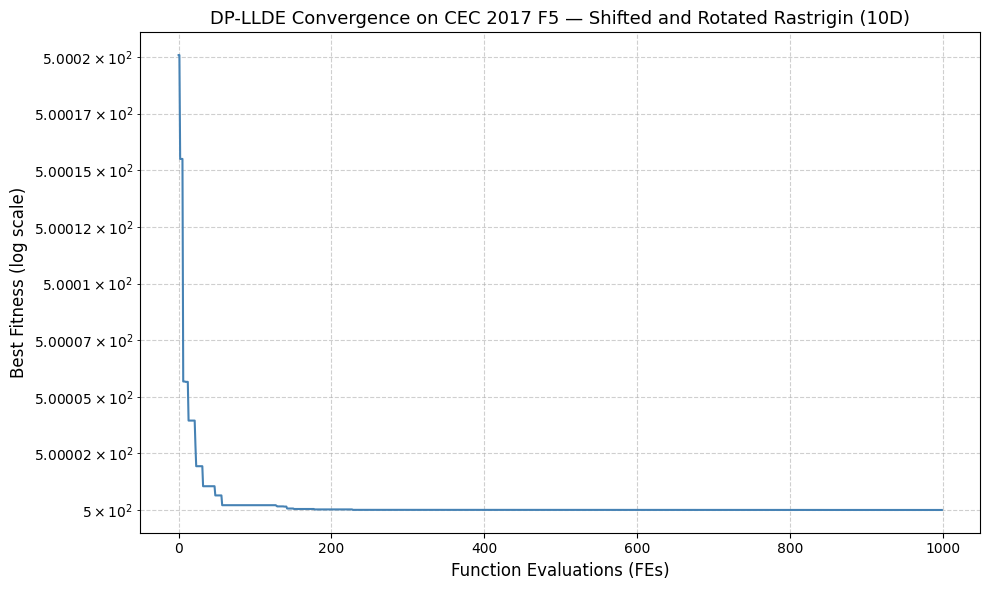

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F5 — Shifted and Rotated Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F5.png', dpi=150)
plt.show()

### **F6**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F6 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F62017(ndim=D)
print(f'\nFunction       : F6 — Shifted and Rotated Expanded Schaffer F6 ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F6 — Single Run
opfunu CEC 2017 loaded!

Function       : F6 — Shifted and Rotated Expanded Schaffer F6 (10D)
Bounds         : [-100.  100.]
Global optimum : 600.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 5.658881e+05
Generation   10: Best = 6.323972e+04  FES =   1100  μ_F = 0.569  μ_CR = 0.354
Generation   20: Best = 8.266350e+03  FES =   2100  μ_F = 0.635  μ_CR = 0.363
Generation   30: Best = 1.385679e+03  FES =   3100  μ_F = 0.688  μ_CR = 0.368
Generation   40: Best = 7.427524e+02  FES =   4100  μ_F = 0.726  μ_CR = 0.367
Generation   50: Best = 6.872953e+02  FES =   5100  μ_F = 0.754  μ_CR = 0.373
Generation   60: Best = 6.636285e+02  FES =   6100  μ_F = 0.777  μ_CR = 0.373
Generation   70: Best = 6.636285e+02  FES =   7100  μ_F = 0.770  μ_CR = 0.356
Generation   80: Best = 6.583148e+02  FES =   8100  μ_F = 0.754  μ_CR = 0.346
Generation   90: Best = 6.538038e+02  FES =   9100  μ_F = 0.767  μ_CR = 0.336
Generati

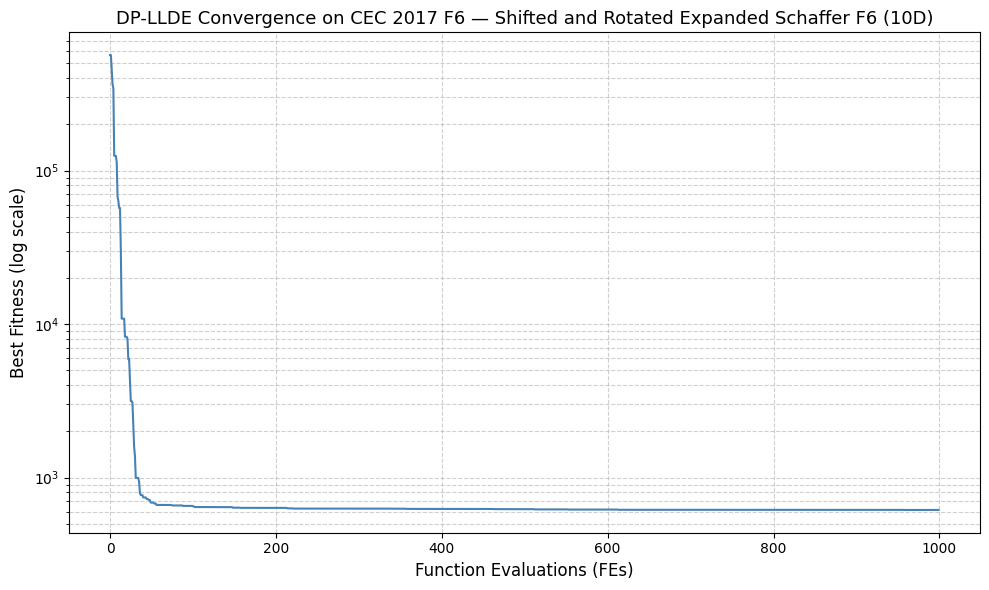

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F6 — Shifted and Rotated Expanded Schaffer F6 (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F6.png', dpi=150)
plt.show()

### **F7**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F7 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F72017(ndim=D)
print(f'\nFunction       : F7 — Shifted and Rotated Lunacek Bi-Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F7 — Single Run
opfunu CEC 2017 loaded!

Function       : F7 — Shifted and Rotated Lunacek Bi-Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 700.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 9.668244e+02
Generation   10: Best = 7.624767e+02  FES =   1100  μ_F = 0.582  μ_CR = 0.346
Generation   20: Best = 7.624767e+02  FES =   2100  μ_F = 0.648  μ_CR = 0.337
Generation   30: Best = 7.624767e+02  FES =   3100  μ_F = 0.695  μ_CR = 0.316
Generation   40: Best = 7.482619e+02  FES =   4100  μ_F = 0.744  μ_CR = 0.285
Generation   50: Best = 7.482619e+02  FES =   5100  μ_F = 0.776  μ_CR = 0.241
Generation   60: Best = 7.482619e+02  FES =   6100  μ_F = 0.786  μ_CR = 0.221
Generation   70: Best = 7.482619e+02  FES =   7100  μ_F = 0.787  μ_CR = 0.176
Generation   80: Best = 7.482619e+02  FES =   8100  μ_F = 0.814  μ_CR = 0.162
Generation   90: Best = 7.380993e+02  FES =   9100  μ_F = 0.823  μ_CR = 0.146
Generati

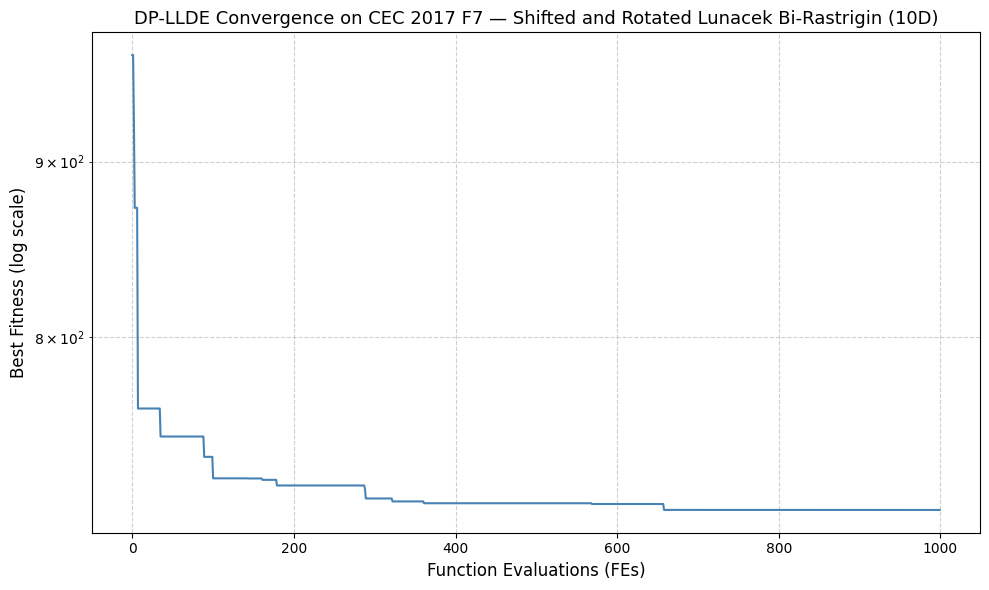

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F7 — Shifted and Rotated Lunacek Bi-Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F7.png', dpi=150)
plt.show()

### **F8**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F8 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F82017(ndim=D)
print(f'\nFunction       : F8 — Shifted and Rotated Non-Continuous Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F8 — Single Run
opfunu CEC 2017 loaded!

Function       : F8 — Shifted and Rotated Non-Continuous Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 800.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 8.111359e+02
Generation   10: Best = 8.024712e+02  FES =   1100  μ_F = 0.584  μ_CR = 0.347
Generation   20: Best = 8.015919e+02  FES =   2100  μ_F = 0.637  μ_CR = 0.347
Generation   30: Best = 8.002857e+02  FES =   3100  μ_F = 0.666  μ_CR = 0.352
Generation   40: Best = 8.002071e+02  FES =   4100  μ_F = 0.701  μ_CR = 0.344
Generation   50: Best = 8.001313e+02  FES =   5100  μ_F = 0.733  μ_CR = 0.348
Generation   60: Best = 8.000377e+02  FES =   6100  μ_F = 0.744  μ_CR = 0.339
Generation   70: Best = 8.000120e+02  FES =   7100  μ_F = 0.766  μ_CR = 0.343
Generation   80: Best = 8.000019e+02  FES =   8100  μ_F = 0.766  μ_CR = 0.347
Generation   90: Best = 8.000004e+02  FES =   9100  μ_F = 0.781  μ_CR = 0.357
Gene

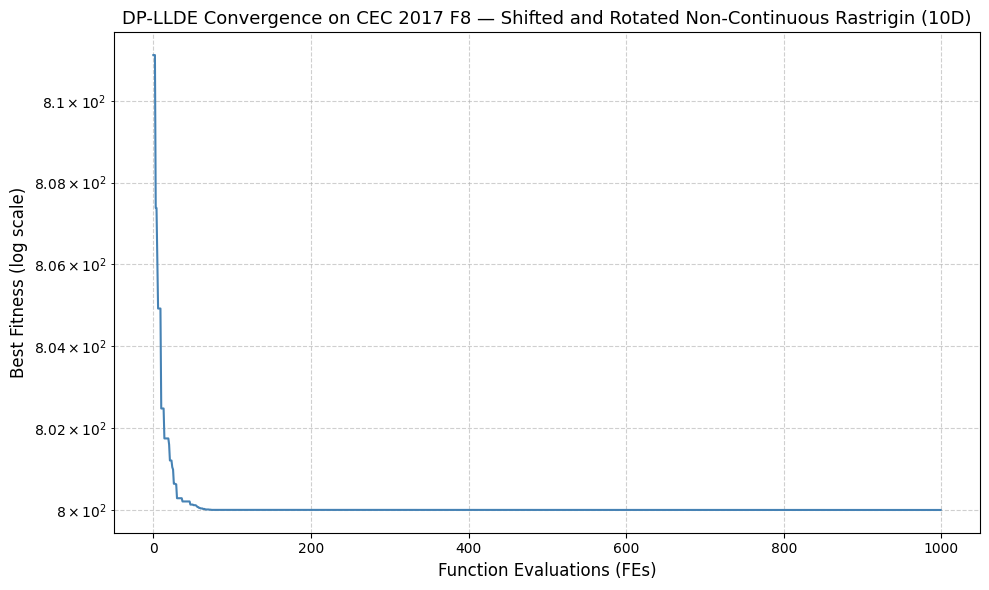

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F8 — Shifted and Rotated Non-Continuous Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F8.png', dpi=150)
plt.show()

### **F9 (Negative Offset)**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F9 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F92017(ndim=D)
print(f'\nFunction       : F9 — Shifted and Rotated Levy ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F9 — Single Run
opfunu CEC 2017 loaded!

Function       : F9 — Shifted and Rotated Levy (10D)
Bounds         : [-100.  100.]
Global optimum : 900.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.378017e+03
Generation   10: Best = 5.729587e+02  FES =   1100  μ_F = 0.586  μ_CR = 0.336
Generation   20: Best = 3.134854e+02  FES =   2100  μ_F = 0.670  μ_CR = 0.319
Generation   30: Best = -5.641454e+02  FES =   3100  μ_F = 0.694  μ_CR = 0.295
Generation   40: Best = -9.590324e+02  FES =   4100  μ_F = 0.751  μ_CR = 0.266
Generation   50: Best = -9.590324e+02  FES =   5100  μ_F = 0.769  μ_CR = 0.237
Generation   60: Best = -9.590324e+02  FES =   6100  μ_F = 0.806  μ_CR = 0.207
Generation   70: Best = -9.590324e+02  FES =   7100  μ_F = 0.805  μ_CR = 0.178
Generation   80: Best = -1.134917e+03  FES =   8100  μ_F = 0.817  μ_CR = 0.134
Generation   90: Best = -1.150325e+03  FES =   9100  μ_F = 0.816  μ_CR = 0.109
Generation  100: 

F9 produces negative fitness values due to opfunu's shift offset — known implementation issue

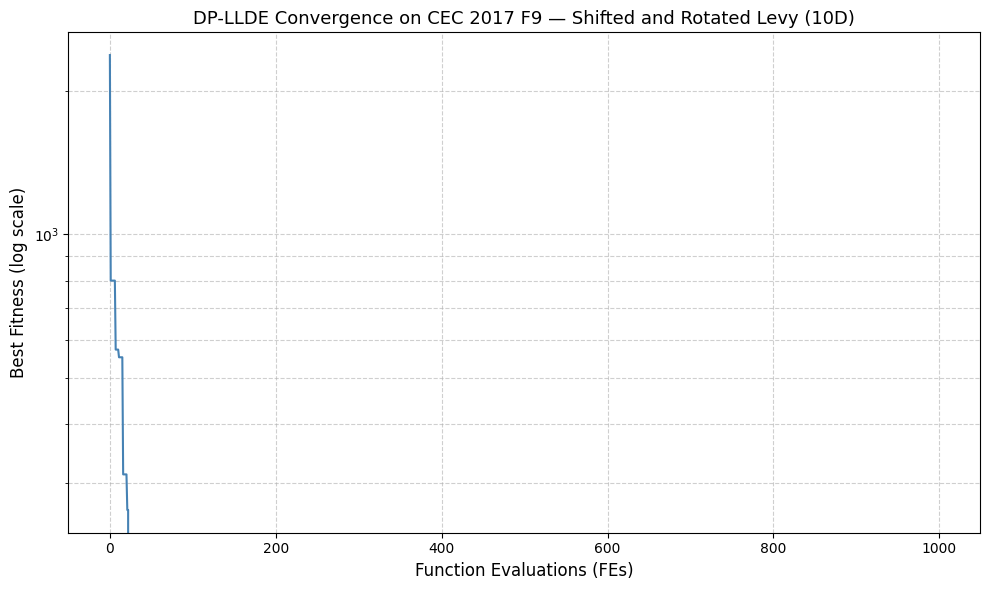

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F9 — Shifted and Rotated Levy (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F9.png', dpi=150)
plt.show()

### **F10**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F10 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F102017(ndim=D)
print(f'\nFunction       : F10 — Shifted and Rotated Schwefel ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F10 — Single Run
opfunu CEC 2017 loaded!

Function       : F10 — Shifted and Rotated Schwefel (10D)
Bounds         : [-100.  100.]
Global optimum : 1000.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.486353e+05
Generation   10: Best = 2.443054e+04  FES =   1100  μ_F = 0.600  μ_CR = 0.353
Generation   20: Best = 9.945618e+03  FES =   2100  μ_F = 0.662  μ_CR = 0.346
Generation   30: Best = 7.715455e+03  FES =   3100  μ_F = 0.698  μ_CR = 0.349
Generation   40: Best = 5.089146e+03  FES =   4100  μ_F = 0.716  μ_CR = 0.334
Generation   50: Best = 4.656661e+03  FES =   5100  μ_F = 0.737  μ_CR = 0.325
Generation   60: Best = 3.676130e+03  FES =   6100  μ_F = 0.750  μ_CR = 0.298
Generation   70: Best = 2.442955e+03  FES =   7100  μ_F = 0.749  μ_CR = 0.304
Generation   80: Best = 1.962300e+03  FES =   8100  μ_F = 0.776  μ_CR = 0.290
Generation   90: Best = 1.962300e+03  FES =   9100  μ_F = 0.759  μ_CR = 0.276
Generation  100: 

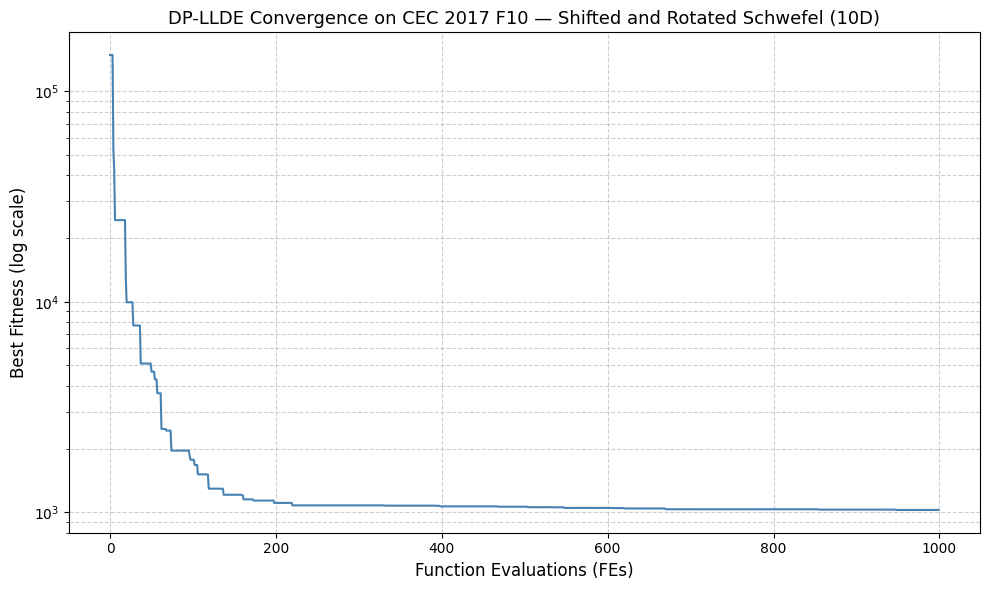

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F10 — Shifted and Rotated Schwefel (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F10.png', dpi=150)
plt.show()

### **2.3.3. Hybrid Functions (F11-F20)**

---



### **F11**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F11 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F112017(ndim=D)
print(f'\nFunction       : F11 — Zahkarov; Rosenbrock; Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F11 — Single Run
opfunu CEC 2017 loaded!

Function       : F11 — Zahkarov; Rosenbrock; Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 1100.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.013182e+09
Generation   10: Best = 3.871202e+08  FES =   1100  μ_F = 0.587  μ_CR = 0.351
Generation   20: Best = 3.936718e+07  FES =   2100  μ_F = 0.652  μ_CR = 0.351
Generation   30: Best = 3.936718e+07  FES =   3100  μ_F = 0.709  μ_CR = 0.366
Generation   40: Best = 2.507618e+07  FES =   4100  μ_F = 0.754  μ_CR = 0.332
Generation   50: Best = 2.507618e+07  FES =   5100  μ_F = 0.773  μ_CR = 0.334
Generation   60: Best = 8.482845e+06  FES =   6100  μ_F = 0.767  μ_CR = 0.323
Generation   70: Best = 8.482845e+06  FES =   7100  μ_F = 0.762  μ_CR = 0.325
Generation   80: Best = 8.482845e+06  FES =   8100  μ_F = 0.789  μ_CR = 0.321
Generation   90: Best = 8.482845e+06  FES =   9100  μ_F = 0.821  μ_CR = 0.305
Generation  10

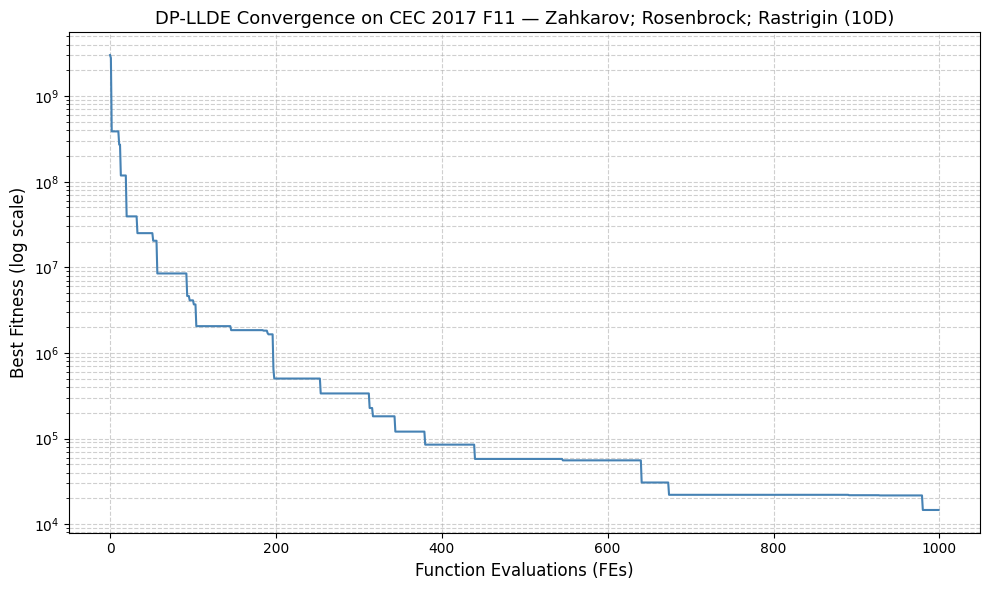

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F11 — Zahkarov; Rosenbrock; Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F11.png', dpi=150)
plt.show()

### **F12**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F12 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F122017(ndim=D)
print(f'\nFunction       : F12 — High-conditioned Elliptic; Modified Schwefel; Bent Cigar ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F12 — Single Run
opfunu CEC 2017 loaded!

Function       : F12 — High-conditioned Elliptic; Modified Schwefel; Bent Cigar (10D)
Bounds         : [-100.  100.]
Global optimum : 1200.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.656552e+09
Generation   10: Best = 1.924623e+07  FES =   1100  μ_F = 0.572  μ_CR = 0.355
Generation   20: Best = 6.058832e+05  FES =   2100  μ_F = 0.643  μ_CR = 0.359
Generation   30: Best = 1.864763e+05  FES =   3100  μ_F = 0.673  μ_CR = 0.357
Generation   40: Best = 1.864763e+05  FES =   4100  μ_F = 0.710  μ_CR = 0.362
Generation   50: Best = 1.864763e+05  FES =   5100  μ_F = 0.717  μ_CR = 0.355
Generation   60: Best = 1.093501e+05  FES =   6100  μ_F = 0.721  μ_CR = 0.359
Generation   70: Best = 1.093501e+05  FES =   7100  μ_F = 0.739  μ_CR = 0.361
Generation   80: Best = 6.969452e+04  FES =   8100  μ_F = 0.755  μ_CR = 0.361
Generation   90: Best = 4.614526e+04  FES =   9100  μ_F = 0.797  μ_

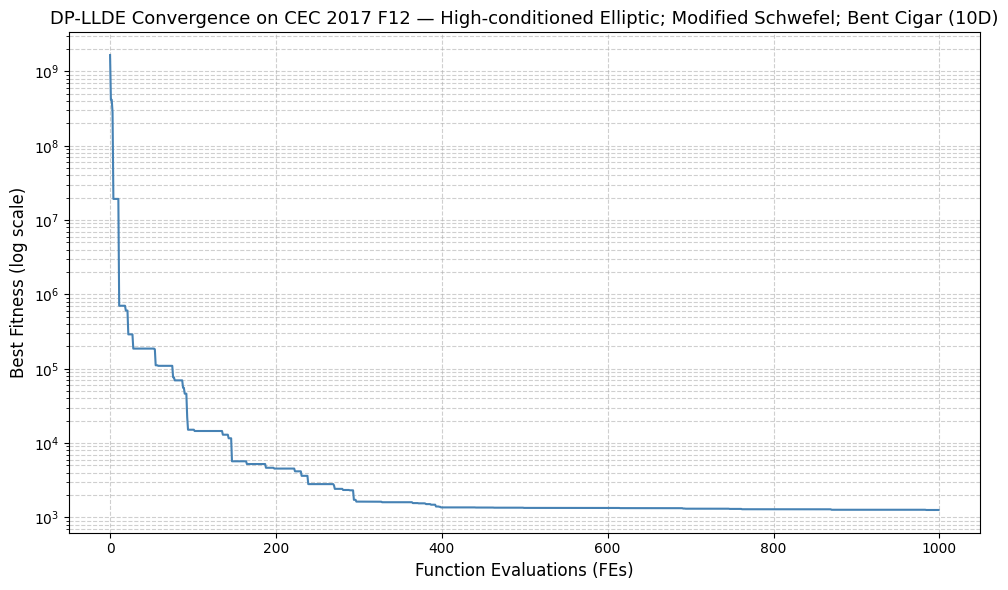

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F12 — High-conditioned Elliptic; Modified Schwefel; Bent Cigar (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F12.png', dpi=150)
plt.show()

### **F13**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F13 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F132017(ndim=D)
print(f'\nFunction       : F13 — Bent Cigar; Rosenbrock; Lunacek bi-Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F13 — Single Run
opfunu CEC 2017 loaded!

Function       : F13 — Bent Cigar; Rosenbrock; Lunacek bi-Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 1300.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.494421e+05
Generation   10: Best = 5.963296e+04  FES =   1100  μ_F = 0.593  μ_CR = 0.350
Generation   20: Best = 1.152331e+04  FES =   2100  μ_F = 0.658  μ_CR = 0.361
Generation   30: Best = 5.954154e+03  FES =   3100  μ_F = 0.697  μ_CR = 0.361
Generation   40: Best = 5.954154e+03  FES =   4100  μ_F = 0.745  μ_CR = 0.341
Generation   50: Best = 3.938706e+03  FES =   5100  μ_F = 0.794  μ_CR = 0.329
Generation   60: Best = 2.854587e+03  FES =   6100  μ_F = 0.805  μ_CR = 0.308
Generation   70: Best = 2.254629e+03  FES =   7100  μ_F = 0.778  μ_CR = 0.308
Generation   80: Best = 1.886410e+03  FES =   8100  μ_F = 0.781  μ_CR = 0.299
Generation   90: Best = 1.886410e+03  FES =   9100  μ_F = 0.803  μ_CR = 0.275
G

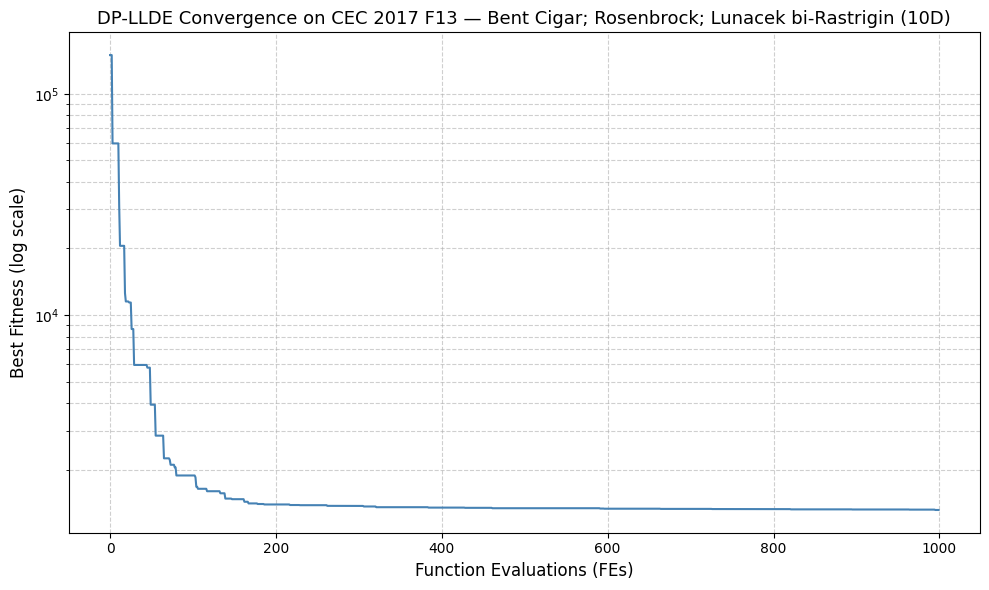

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F13 — Bent Cigar; Rosenbrock; Lunacek bi-Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F13.png', dpi=150)
plt.show()

### **F14**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F14 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F142017(ndim=D)
print(f'\nFunction       : F14 — High-conditioned Elliptic; Ackley; Schaffer F7; Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F14 — Single Run
opfunu CEC 2017 loaded!

Function       : F14 — High-conditioned Elliptic; Ackley; Schaffer F7; Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 1400.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.907984e+08
Generation   10: Best = 1.262743e+06  FES =   1100  μ_F = 0.587  μ_CR = 0.348
Generation   20: Best = 1.408462e+05  FES =   2100  μ_F = 0.651  μ_CR = 0.354
Generation   30: Best = 1.237782e+05  FES =   3100  μ_F = 0.725  μ_CR = 0.348
Generation   40: Best = 3.031899e+04  FES =   4100  μ_F = 0.733  μ_CR = 0.343
Generation   50: Best = 2.473260e+04  FES =   5100  μ_F = 0.772  μ_CR = 0.333
Generation   60: Best = 1.366242e+04  FES =   6100  μ_F = 0.788  μ_CR = 0.300
Generation   70: Best = 1.147486e+04  FES =   7100  μ_F = 0.801  μ_CR = 0.293
Generation   80: Best = 6.867718e+03  FES =   8100  μ_F = 0.783  μ_CR = 0.272
Generation   90: Best = 6.867718e+03  FES =   9100  μ_F = 0.801  μ

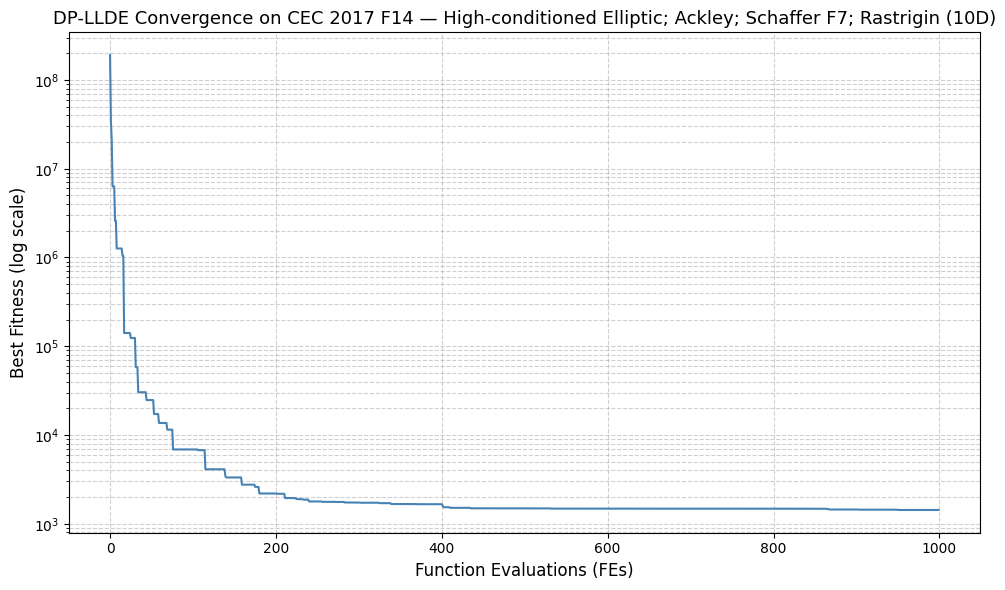

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F14 — High-conditioned Elliptic; Ackley; Schaffer F7; Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F14.png', dpi=150)
plt.show()

### **F15**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F15 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F152017(ndim=D)
print(f'\nFunction       : F15 — Bent Cigar; HGBat; Rastrigin; Rosenbrock ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F15 — Single Run
opfunu CEC 2017 loaded!

Function       : F15 — Bent Cigar; HGBat; Rastrigin; Rosenbrock (10D)
Bounds         : [-100.  100.]
Global optimum : 1500.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.682342e+05
Generation   10: Best = 4.657909e+04  FES =   1100  μ_F = 0.594  μ_CR = 0.359
Generation   20: Best = 7.824723e+03  FES =   2100  μ_F = 0.653  μ_CR = 0.366
Generation   30: Best = 5.933229e+03  FES =   3100  μ_F = 0.710  μ_CR = 0.365
Generation   40: Best = 2.878831e+03  FES =   4100  μ_F = 0.735  μ_CR = 0.358
Generation   50: Best = 2.230436e+03  FES =   5100  μ_F = 0.769  μ_CR = 0.344
Generation   60: Best = 2.055945e+03  FES =   6100  μ_F = 0.778  μ_CR = 0.321
Generation   70: Best = 1.518087e+03  FES =   7100  μ_F = 0.800  μ_CR = 0.323
Generation   80: Best = 1.467647e+03  FES =   8100  μ_F = 0.819  μ_CR = 0.292
Generation   90: Best = 1.427841e+03  FES =   9100  μ_F = 0.825  μ_CR = 0.272
Gener

Best fitness falls below f_global due to opfunu F15 offset inconsistency — not an algorithm error

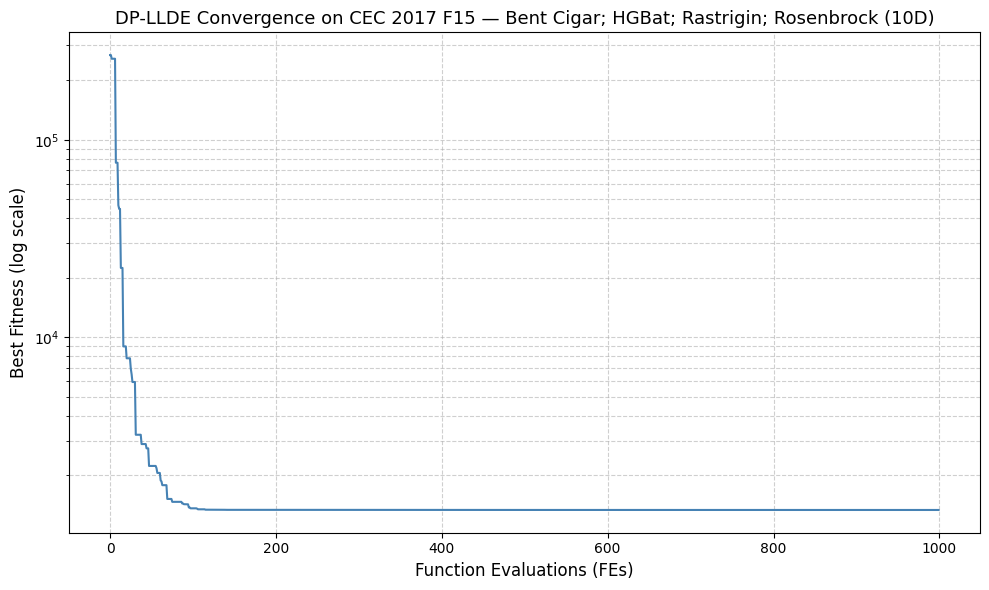

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F15 — Bent Cigar; HGBat; Rastrigin; Rosenbrock (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F15.png', dpi=150)
plt.show()

### **F16 (Positive Offset)**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F16 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F162017(ndim=D)
print(f'\nFunction       : F16 — Expanded Schaffer F6; HGBat; Rosenbrock; Modified Schwefel ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F16 — Single Run
opfunu CEC 2017 loaded!

Function       : F16 — Expanded Schaffer F6; HGBat; Rosenbrock; Modified Schwefel (10D)
Bounds         : [-100.  100.]
Global optimum : 1600.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.478775e+09
Generation   10: Best = 1.489701e+05  FES =   1100  μ_F = 0.585  μ_CR = 0.350
Generation   20: Best = 1.236006e+04  FES =   2100  μ_F = 0.638  μ_CR = 0.353
Generation   30: Best = 6.308466e+03  FES =   3100  μ_F = 0.672  μ_CR = 0.370
Generation   40: Best = 6.308466e+03  FES =   4100  μ_F = 0.716  μ_CR = 0.362
Generation   50: Best = 2.534060e+03  FES =   5100  μ_F = 0.751  μ_CR = 0.359
Generation   60: Best = 2.534060e+03  FES =   6100  μ_F = 0.757  μ_CR = 0.319
Generation   70: Best = 2.401166e+03  FES =   7100  μ_F = 0.773  μ_CR = 0.303
Generation   80: Best = 2.401166e+03  FES =   8100  μ_F = 0.762  μ_CR = 0.271
Generation   90: Best = 2.041383e+03  FES =   9100  μ_F = 0.781  

Best fitness falls below f_global due to opfunu F16 offset inconsistency — not an algorithm error

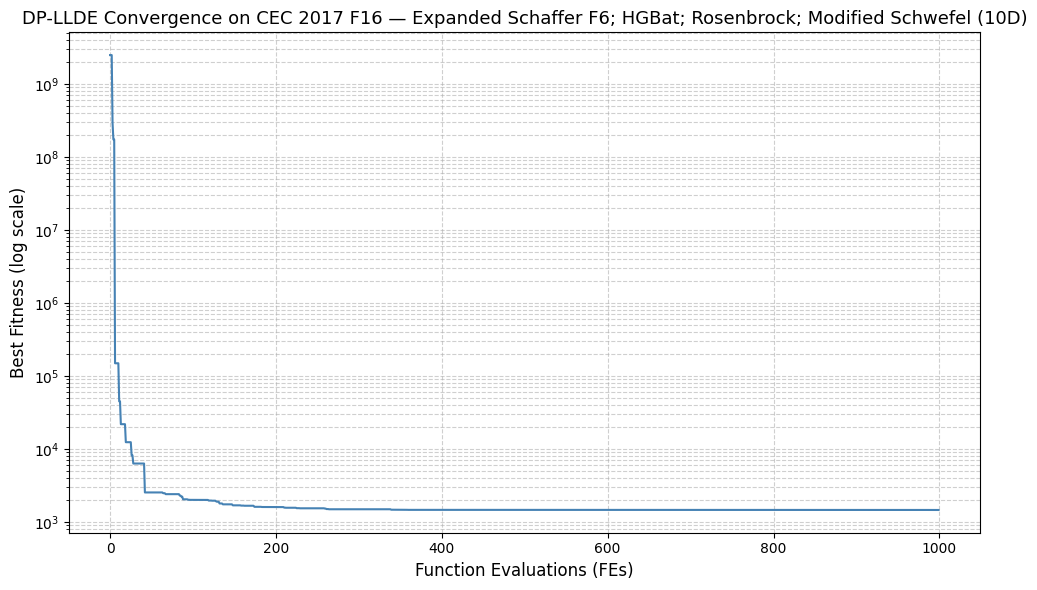

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F16 — Expanded Schaffer F6; HGBat; Rosenbrock; Modified Schwefel (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F16.png', dpi=150)
plt.show()

### **F17 (opfunu error)**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F17 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

import numpy as np

D = 10
func_obj = cec2017.F172017(ndim=D)
print(f'\nFunction       : F17 — Katsuura; Ackley; Expanded Griewank plus Rosenbrock; Schwefel; Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

# Note: F17 returns nan due to numerical overflow in opfunu's Katsuura component.
# A finite penalty (1e18) is applied to nan evaluations to allow the algorithm to proceed.
def safe_eval(x):
    val = func_obj.evaluate(x)
    return val if np.isfinite(val) else 1e18

opt = DPLLDE(
    objective_func=safe_eval,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F17 — Single Run
opfunu CEC 2017 loaded!

Function       : F17 — Katsuura; Ackley; Expanded Griewank plus Rosenbrock; Schwefel; Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 1700.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.000000e+18
Generation   10: Best = 1.000000e+18  FES =   1100  μ_F = 0.594  μ_CR = 0.354
Generation   20: Best = 1.000000e+18  FES =   2100  μ_F = 0.670  μ_CR = 0.355
Generation   30: Best = 1.000000e+18  FES =   3100  μ_F = 0.730  μ_CR = 0.359
Generation   40: Best = 1.000000e+18  FES =   4100  μ_F = 0.774  μ_CR = 0.353
Generation   50: Best = 1.000000e+18  FES =   5100  μ_F = 0.810  μ_CR = 0.355
Generation   60: Best = 1.000000e+18  FES =   6100  μ_F = 0.831  μ_CR = 0.353
Generation   70: Best = 1.000000e+18  FES =   7100  μ_F = 0.848  μ_CR = 0.358
Generation   80: Best = 1.000000e+18  FES =   8100  μ_F = 0.857  μ_CR = 0.356
Generation   90: Best = 1.000000e+18  FES =   9100 

F17 is skipped — opfunu's F17 (CEC 2017) returns nan for all evaluations in 10D due to numerical overflow in the Katsuura component.

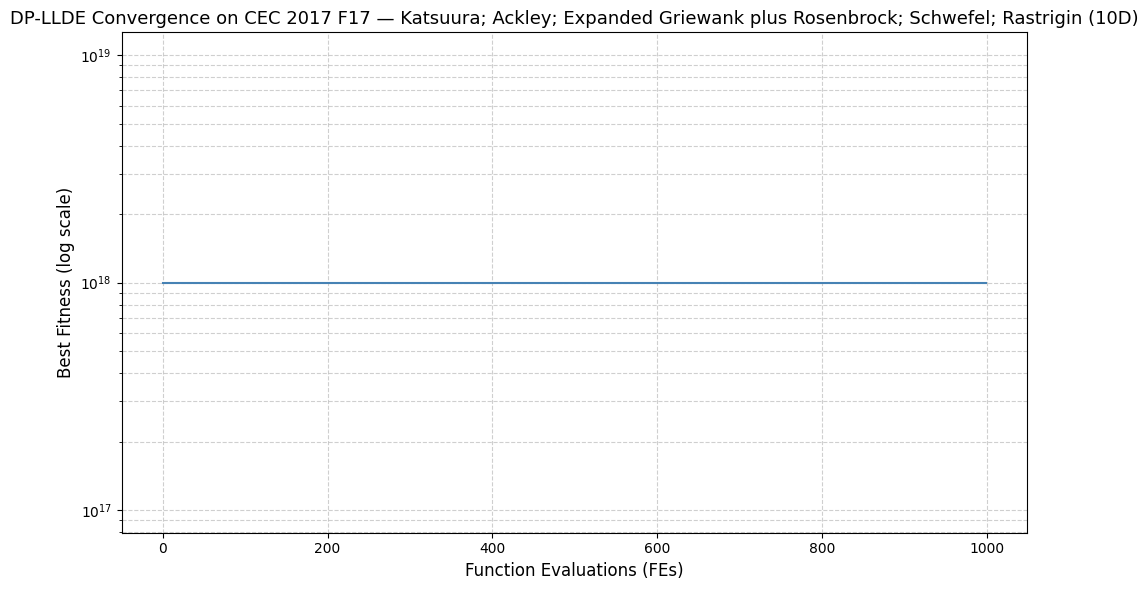

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F17 — Katsuura; Ackley; Expanded Griewank plus Rosenbrock; Schwefel; Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F17.png', dpi=150)
plt.show()

### **F18**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F18 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F182017(ndim=D)
print(f'\nFunction       : F18 — High-conditioned Elliptic; Ackley; Rastrigin; HGBat; Discus ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F18 — Single Run
opfunu CEC 2017 loaded!

Function       : F18 — High-conditioned Elliptic; Ackley; Rastrigin; HGBat; Discus (10D)
Bounds         : [-100.  100.]
Global optimum : 1800.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.379099e+09
Generation   10: Best = 2.101981e+07  FES =   1100  μ_F = 0.586  μ_CR = 0.351
Generation   20: Best = 3.831647e+04  FES =   2100  μ_F = 0.664  μ_CR = 0.353
Generation   30: Best = 1.884372e+04  FES =   3100  μ_F = 0.719  μ_CR = 0.364
Generation   40: Best = 1.364639e+04  FES =   4100  μ_F = 0.770  μ_CR = 0.364
Generation   50: Best = 7.094409e+03  FES =   5100  μ_F = 0.812  μ_CR = 0.365
Generation   60: Best = 2.496223e+03  FES =   6100  μ_F = 0.818  μ_CR = 0.353
Generation   70: Best = 2.496223e+03  FES =   7100  μ_F = 0.830  μ_CR = 0.354
Generation   80: Best = 2.026274e+03  FES =   8100  μ_F = 0.829  μ_CR = 0.351
Generation   90: Best = 1.870819e+03  FES =   9100  μ_F = 0.835 

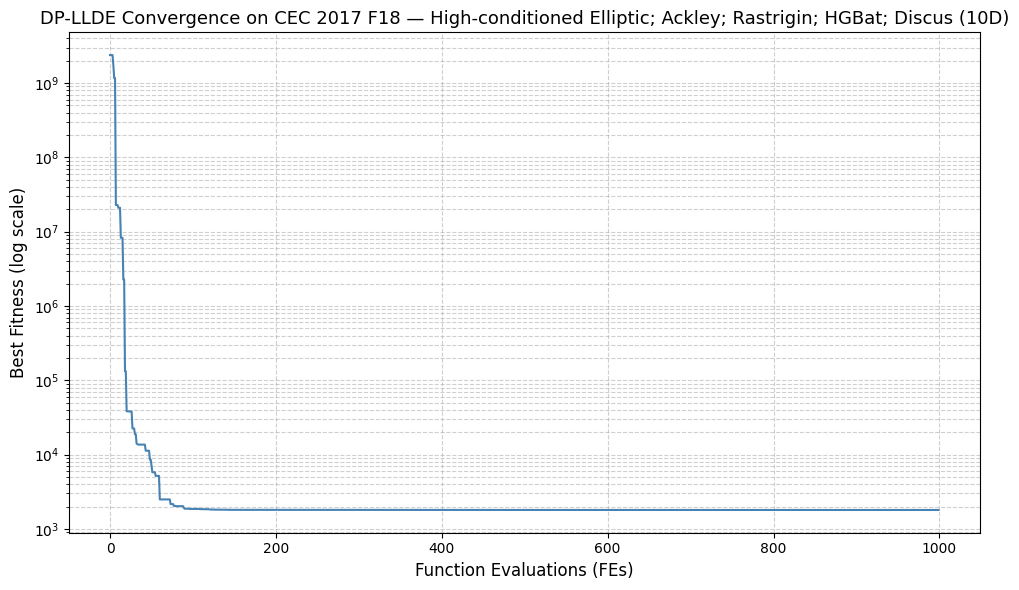

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F18 — High-conditioned Elliptic; Ackley; Rastrigin; HGBat; Discus (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F18.png', dpi=150)
plt.show()

### **F19**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F19 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F192017(ndim=D)
print(f'\nFunction       : F19 — Bent Cigar; Rastrigin; Griewank plus Rosenbrock; Weierstrass; Expanded Schaffer F6 ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F19 — Single Run
opfunu CEC 2017 loaded!

Function       : F19 — Bent Cigar; Rastrigin; Griewank plus Rosenbrock; Weierstrass; Expanded Schaffer F6 (10D)
Bounds         : [-100.  100.]
Global optimum : 1900.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 5.886494e+03
Generation   10: Best = 2.452266e+03  FES =   1100  μ_F = 0.576  μ_CR = 0.342
Generation   20: Best = 2.360078e+03  FES =   2100  μ_F = 0.634  μ_CR = 0.336
Generation   30: Best = 1.970985e+03  FES =   3100  μ_F = 0.682  μ_CR = 0.320
Generation   40: Best = 1.916088e+03  FES =   4100  μ_F = 0.720  μ_CR = 0.296
Generation   50: Best = 1.898526e+03  FES =   5100  μ_F = 0.771  μ_CR = 0.278
Generation   60: Best = 1.862800e+03  FES =   6100  μ_F = 0.781  μ_CR = 0.249
Generation   70: Best = 1.842991e+03  FES =   7100  μ_F = 0.805  μ_CR = 0.225
Generation   80: Best = 1.842664e+03  FES =   8100  μ_F = 0.820  μ_CR = 0.188
Generation   90: Best = 1.842467e+03  FES

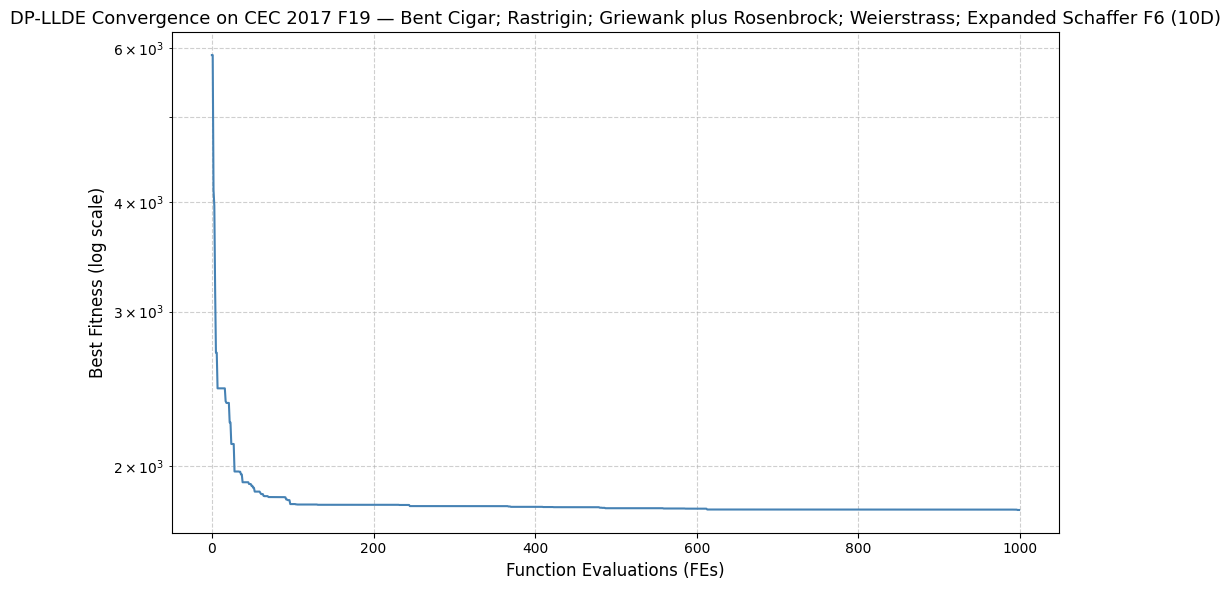

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F19 — Bent Cigar; Rastrigin; Griewank plus Rosenbrock; Weierstrass; Expanded Schaffer F6 (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F19.png', dpi=150)
plt.show()

### **F20**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F20 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F202017(ndim=D)
print(f'\nFunction       : F20 — HappyCat; Katsuura; Ackley; Rastrigin; Modified Schwefel; Schaffer F7 ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F20 — Single Run
opfunu CEC 2017 loaded!

Function       : F20 — HappyCat; Katsuura; Ackley; Rastrigin; Modified Schwefel; Schaffer F7 (10D)
Bounds         : [-100.  100.]
Global optimum : 2000.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 5.947707e+03
Generation   10: Best = 3.325903e+03  FES =   1100  μ_F = 0.582  μ_CR = 0.348
Generation   20: Best = 2.641190e+03  FES =   2100  μ_F = 0.641  μ_CR = 0.365
Generation   30: Best = 2.427315e+03  FES =   3100  μ_F = 0.666  μ_CR = 0.373
Generation   40: Best = 2.273034e+03  FES =   4100  μ_F = 0.688  μ_CR = 0.370
Generation   50: Best = 2.140714e+03  FES =   5100  μ_F = 0.725  μ_CR = 0.369
Generation   60: Best = 2.118921e+03  FES =   6100  μ_F = 0.758  μ_CR = 0.374
Generation   70: Best = 2.107077e+03  FES =   7100  μ_F = 0.778  μ_CR = 0.382
Generation   80: Best = 2.101215e+03  FES =   8100  μ_F = 0.791  μ_CR = 0.380
Generation   90: Best = 2.100801e+03  FES =   9100  μ_

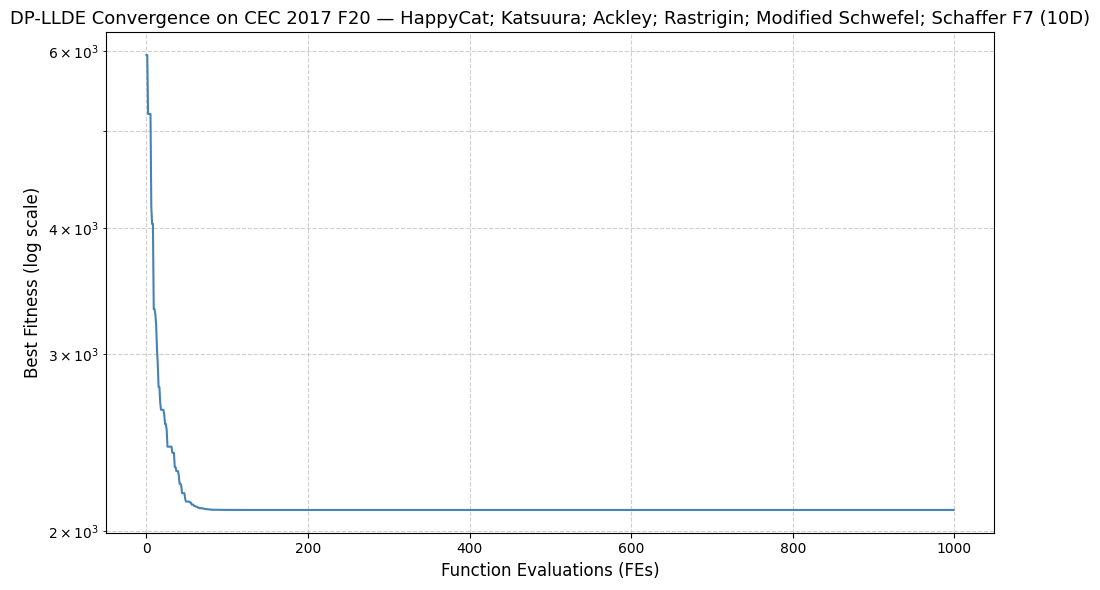

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F20 — HappyCat; Katsuura; Ackley; Rastrigin; Modified Schwefel; Schaffer F7 (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F20.png', dpi=150)
plt.show()

### **2.3.4. Composite Functions (F21-F30)**

---



### **F21 (Negative Offset)**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F21 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F212017(ndim=D)
print(f'\nFunction       : F21 — Rosenbrock; High-conditioned Elliptic; Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F21 — Single Run
opfunu CEC 2017 loaded!

Function       : F21 — Rosenbrock; High-conditioned Elliptic; Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 2100.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 2.277457e+03
Generation   10: Best = 2.234074e+03  FES =   1100  μ_F = 0.590  μ_CR = 0.348
Generation   20: Best = 2.032426e+03  FES =   2100  μ_F = 0.643  μ_CR = 0.354
Generation   30: Best = 2.032426e+03  FES =   3100  μ_F = 0.691  μ_CR = 0.353
Generation   40: Best = 2.032426e+03  FES =   4100  μ_F = 0.714  μ_CR = 0.341
Generation   50: Best = 1.850867e+03  FES =   5100  μ_F = 0.736  μ_CR = 0.318
Generation   60: Best = 1.799778e+03  FES =   6100  μ_F = 0.769  μ_CR = 0.288
Generation   70: Best = 1.799778e+03  FES =   7100  μ_F = 0.781  μ_CR = 0.284
Generation   80: Best = 1.624214e+03  FES =   8100  μ_F = 0.765  μ_CR = 0.245
Generation   90: Best = 1.365159e+03  FES =   9100  μ_F = 0.752  μ_CR = 0.2

Some CEC 2017 functions (e.g. F9, F16, F21) produce best fitness valuesbelow the declared f_global due to known offset inconsistencies in opfunu's CEC 2017 implementation. This behavior is consistent with results observed in the baseline study

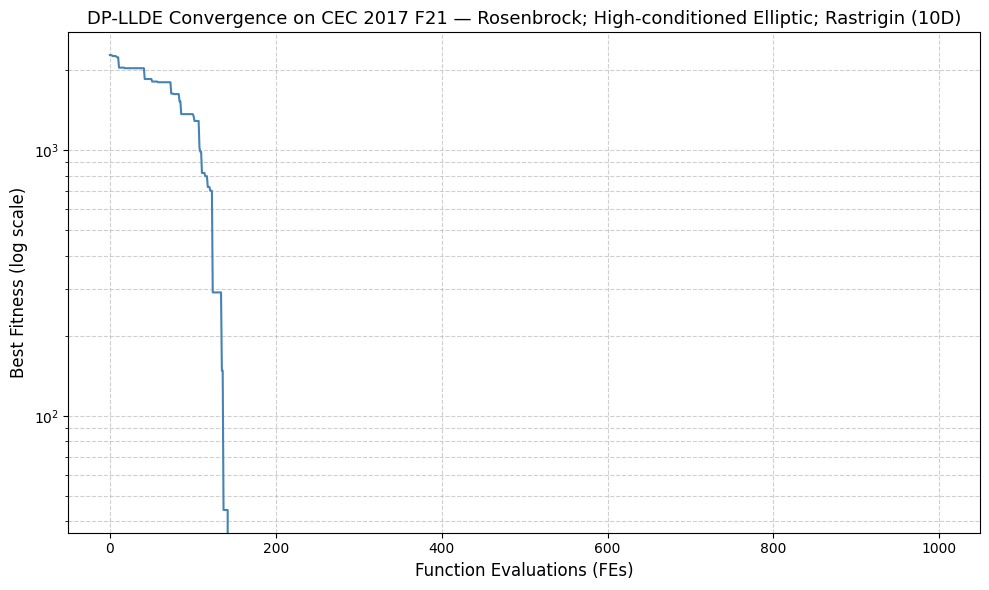

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F21 — Rosenbrock; High-conditioned Elliptic; Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F21.png', dpi=150)
plt.show()

### **F22**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F22 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F222017(ndim=D)
print(f'\nFunction       : F22 — Rastrigin; Griewank; Modified Schwefel ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F22 — Single Run
opfunu CEC 2017 loaded!

Function       : F22 — Rastrigin; Griewank; Modified Schwefel (10D)
Bounds         : [-100.  100.]
Global optimum : 2200.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.000233e+04
Generation   10: Best = 3.541228e+03  FES =   1100  μ_F = 0.585  μ_CR = 0.354
Generation   20: Best = 2.879011e+03  FES =   2100  μ_F = 0.632  μ_CR = 0.356
Generation   30: Best = 2.549133e+03  FES =   3100  μ_F = 0.667  μ_CR = 0.358
Generation   40: Best = 2.405799e+03  FES =   4100  μ_F = 0.713  μ_CR = 0.356
Generation   50: Best = 2.342356e+03  FES =   5100  μ_F = 0.751  μ_CR = 0.366
Generation   60: Best = 2.312591e+03  FES =   6100  μ_F = 0.769  μ_CR = 0.365
Generation   70: Best = 2.305941e+03  FES =   7100  μ_F = 0.786  μ_CR = 0.369
Generation   80: Best = 2.302473e+03  FES =   8100  μ_F = 0.798  μ_CR = 0.373
Generation   90: Best = 2.300661e+03  FES =   9100  μ_F = 0.812  μ_CR = 0.381
Generat

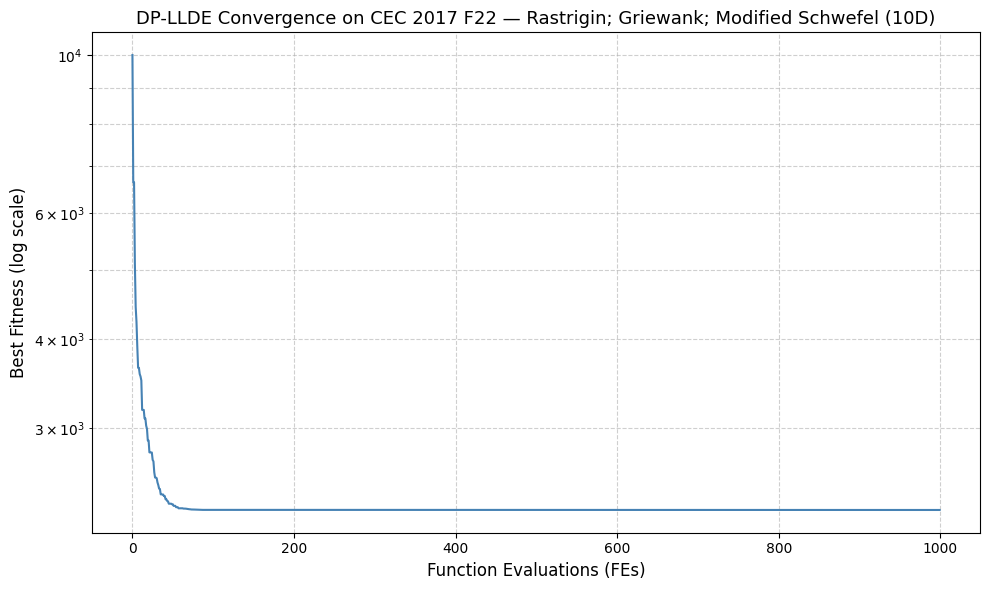

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F22 — Rastrigin; Griewank; Modified Schwefel (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F22.png', dpi=150)
plt.show()

### **F23**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F23 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F232017(ndim=D)
print(f'\nFunction       : F23 — Rosenbrock; Ackley; Modified Schwefel; Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F23 — Single Run
opfunu CEC 2017 loaded!

Function       : F23 — Rosenbrock; Ackley; Modified Schwefel; Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 2300.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 9.005422e+03
Generation   10: Best = 4.512290e+03  FES =   1100  μ_F = 0.584  μ_CR = 0.358
Generation   20: Best = 3.724129e+03  FES =   2100  μ_F = 0.634  μ_CR = 0.369
Generation   30: Best = 2.956237e+03  FES =   3100  μ_F = 0.679  μ_CR = 0.377
Generation   40: Best = 2.580077e+03  FES =   4100  μ_F = 0.720  μ_CR = 0.376
Generation   50: Best = 2.535793e+03  FES =   5100  μ_F = 0.752  μ_CR = 0.381
Generation   60: Best = 2.515662e+03  FES =   6100  μ_F = 0.772  μ_CR = 0.380
Generation   70: Best = 2.504894e+03  FES =   7100  μ_F = 0.788  μ_CR = 0.389
Generation   80: Best = 2.501568e+03  FES =   8100  μ_F = 0.796  μ_CR = 0.388
Generation   90: Best = 2.500526e+03  FES =   9100  μ_F = 0.809  μ_CR = 0.3

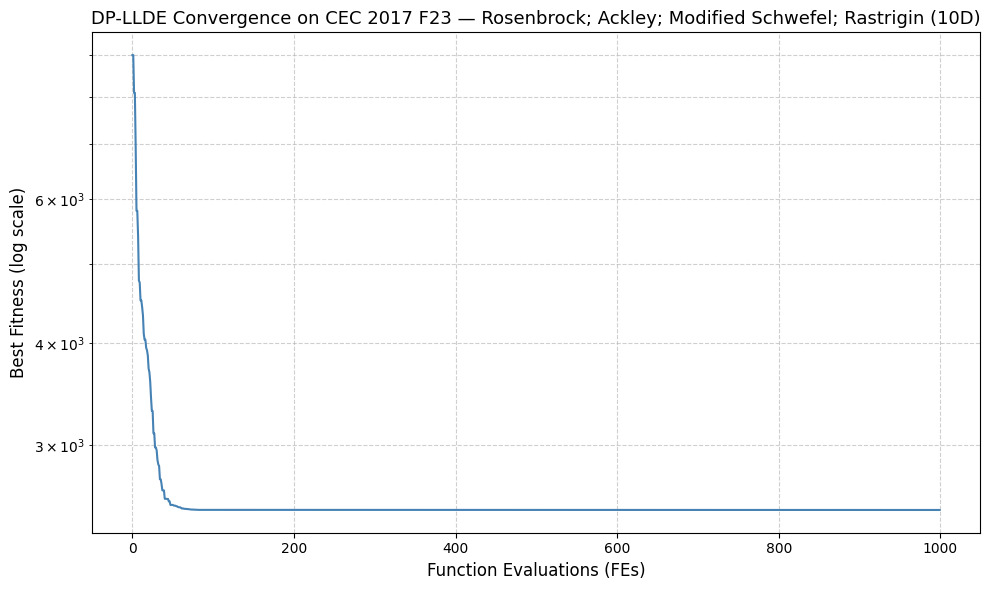

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F23 — Rosenbrock; Ackley; Modified Schwefel; Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F23.png', dpi=150)
plt.show()

### **F24**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F24 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F242017(ndim=D)
print(f'\nFunction       : F24 — Ackley; High-conditioned Elliptic; Griewank; Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F24 — Single Run
opfunu CEC 2017 loaded!

Function       : F24 — Ackley; High-conditioned Elliptic; Griewank; Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 2400.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.564280e+03
Generation   10: Best = 3.132293e+03  FES =   1100  μ_F = 0.573  μ_CR = 0.353
Generation   20: Best = 2.953397e+03  FES =   2100  μ_F = 0.639  μ_CR = 0.361
Generation   30: Best = 2.940997e+03  FES =   3100  μ_F = 0.651  μ_CR = 0.365
Generation   40: Best = 2.893023e+03  FES =   4100  μ_F = 0.674  μ_CR = 0.370
Generation   50: Best = 2.893023e+03  FES =   5100  μ_F = 0.706  μ_CR = 0.379
Generation   60: Best = 2.887731e+03  FES =   6100  μ_F = 0.722  μ_CR = 0.369
Generation   70: Best = 2.884179e+03  FES =   7100  μ_F = 0.745  μ_CR = 0.373
Generation   80: Best = 2.882325e+03  FES =   8100  μ_F = 0.755  μ_CR = 0.376
Generation   90: Best = 2.881100e+03  FES =   9100  μ_F = 0.764  μ_CR

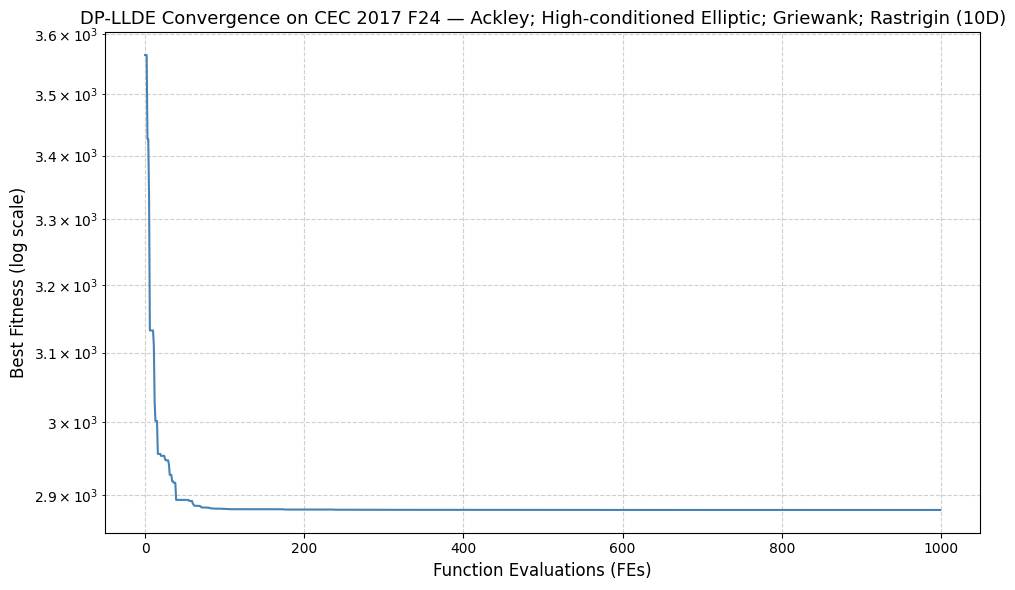

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F24 — Ackley; High-conditioned Elliptic; Griewank; Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F24.png', dpi=150)
plt.show()

### **F25**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F25 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F252017(ndim=D)
print(f'\nFunction       : F25 — Rastrigin; HappyCat; Ackley; Discus; Rosenbrock ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F25 — Single Run
opfunu CEC 2017 loaded!

Function       : F25 — Rastrigin; HappyCat; Ackley; Discus; Rosenbrock (10D)
Bounds         : [-100.  100.]
Global optimum : 2500.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.320394e+03
Generation   10: Best = 3.013065e+03  FES =   1100  μ_F = 0.593  μ_CR = 0.361
Generation   20: Best = 2.969316e+03  FES =   2100  μ_F = 0.661  μ_CR = 0.364
Generation   30: Best = 2.948445e+03  FES =   3100  μ_F = 0.701  μ_CR = 0.355
Generation   40: Best = 2.948445e+03  FES =   4100  μ_F = 0.735  μ_CR = 0.349
Generation   50: Best = 2.947172e+03  FES =   5100  μ_F = 0.764  μ_CR = 0.325
Generation   60: Best = 2.945892e+03  FES =   6100  μ_F = 0.761  μ_CR = 0.313
Generation   70: Best = 2.945892e+03  FES =   7100  μ_F = 0.800  μ_CR = 0.304
Generation   80: Best = 2.945892e+03  FES =   8100  μ_F = 0.794  μ_CR = 0.287
Generation   90: Best = 2.945731e+03  FES =   9100  μ_F = 0.795  μ_CR = 0.28

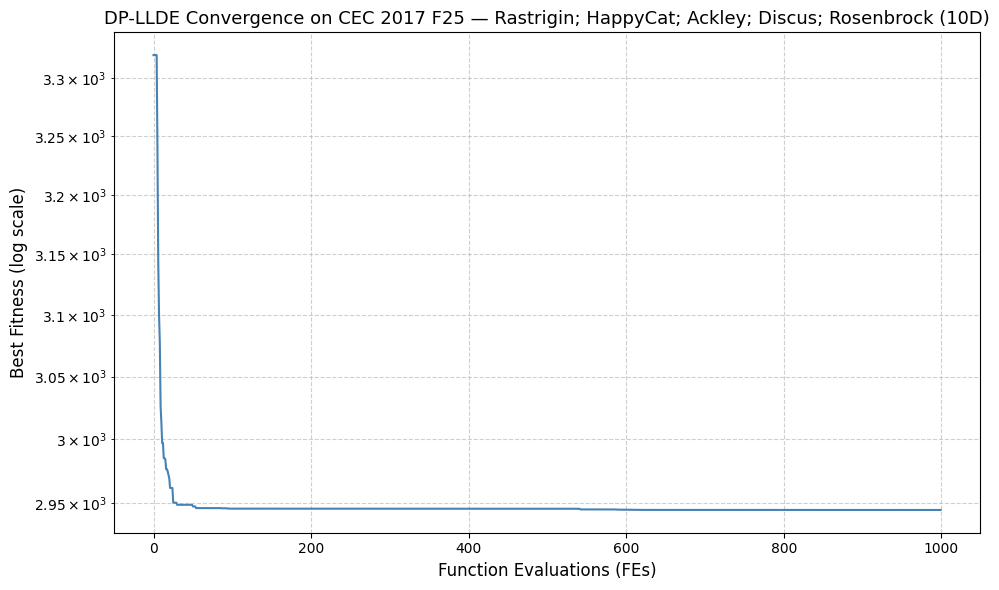

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F25 — Rastrigin; HappyCat; Ackley; Discus; Rosenbrock (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F25.png', dpi=150)
plt.show()

### **F26**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F26 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F262017(ndim=D)
print(f'\nFunction       : F26 — Expanded Schaffer F6; Modified Schwefel; Griewank; Rosenbrock; Rastrigin ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F26 — Single Run
opfunu CEC 2017 loaded!

Function       : F26 — Expanded Schaffer F6; Modified Schwefel; Griewank; Rosenbrock; Rastrigin (10D)
Bounds         : [-100.  100.]
Global optimum : 2600.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.433827e+03
Generation   10: Best = 3.008850e+03  FES =   1100  μ_F = 0.596  μ_CR = 0.352
Generation   20: Best = 2.988817e+03  FES =   2100  μ_F = 0.671  μ_CR = 0.355
Generation   30: Best = 2.987019e+03  FES =   3100  μ_F = 0.704  μ_CR = 0.357
Generation   40: Best = 2.987019e+03  FES =   4100  μ_F = 0.737  μ_CR = 0.364
Generation   50: Best = 2.987019e+03  FES =   5100  μ_F = 0.761  μ_CR = 0.343
Generation   60: Best = 2.983935e+03  FES =   6100  μ_F = 0.766  μ_CR = 0.301
Generation   70: Best = 2.972752e+03  FES =   7100  μ_F = 0.780  μ_CR = 0.259
Generation   80: Best = 2.972752e+03  FES =   8100  μ_F = 0.808  μ_CR = 0.227
Generation   90: Best = 2.970033e+03  FES =   9100 

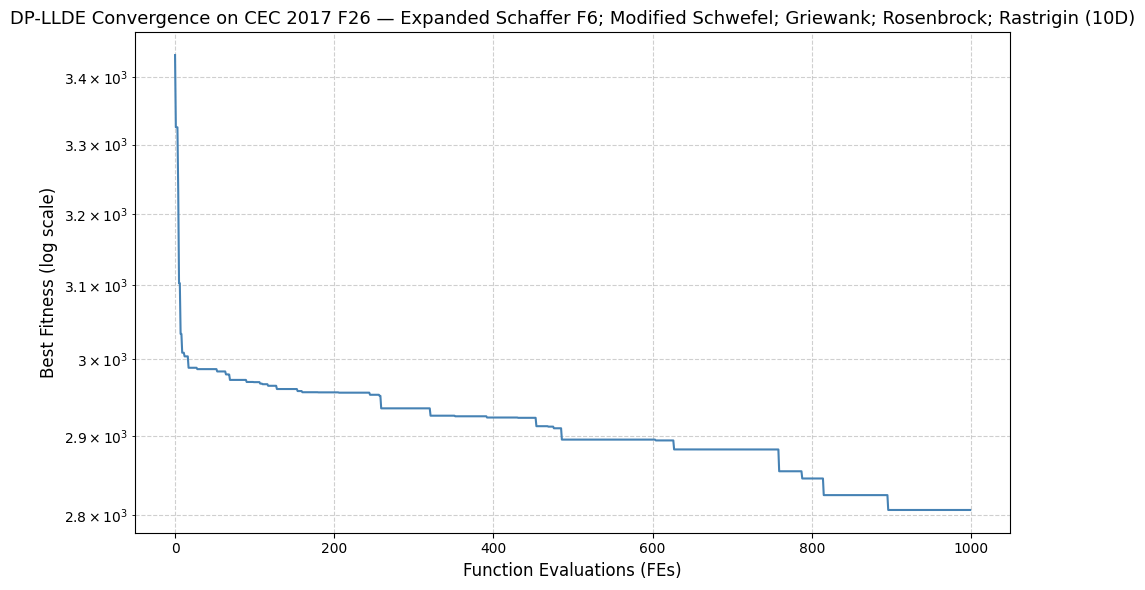

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F26 — Expanded Schaffer F6; Modified Schwefel; Griewank; Rosenbrock; Rastrigin (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F26.png', dpi=150)
plt.show()

### **F27**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F27 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F272017(ndim=D)
print(f'\nFunction       : F27 — HGBat; Rastrigin; Modified Schwfel; Bent Cigar; High-conditioned Elliptic; Expanded Schaffer F6 ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F27 — Single Run
opfunu CEC 2017 loaded!

Function       : F27 — HGBat; Rastrigin; Modified Schwfel; Bent Cigar; High-conditioned Elliptic; Expanded Schaffer F6 (10D)
Bounds         : [-100.  100.]
Global optimum : 2700.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 3.988307e+03
Generation   10: Best = 3.053023e+03  FES =   1100  μ_F = 0.594  μ_CR = 0.348
Generation   20: Best = 3.053023e+03  FES =   2100  μ_F = 0.669  μ_CR = 0.357
Generation   30: Best = 3.043538e+03  FES =   3100  μ_F = 0.711  μ_CR = 0.354
Generation   40: Best = 2.944316e+03  FES =   4100  μ_F = 0.719  μ_CR = 0.361
Generation   50: Best = 2.895310e+03  FES =   5100  μ_F = 0.751  μ_CR = 0.365
Generation   60: Best = 2.820236e+03  FES =   6100  μ_F = 0.758  μ_CR = 0.364
Generation   70: Best = 2.768330e+03  FES =   7100  μ_F = 0.771  μ_CR = 0.364
Generation   80: Best = 2.743043e+03  FES =   8100  μ_F = 0.782  μ_CR = 0.378
Generation   90: Best = 2.72

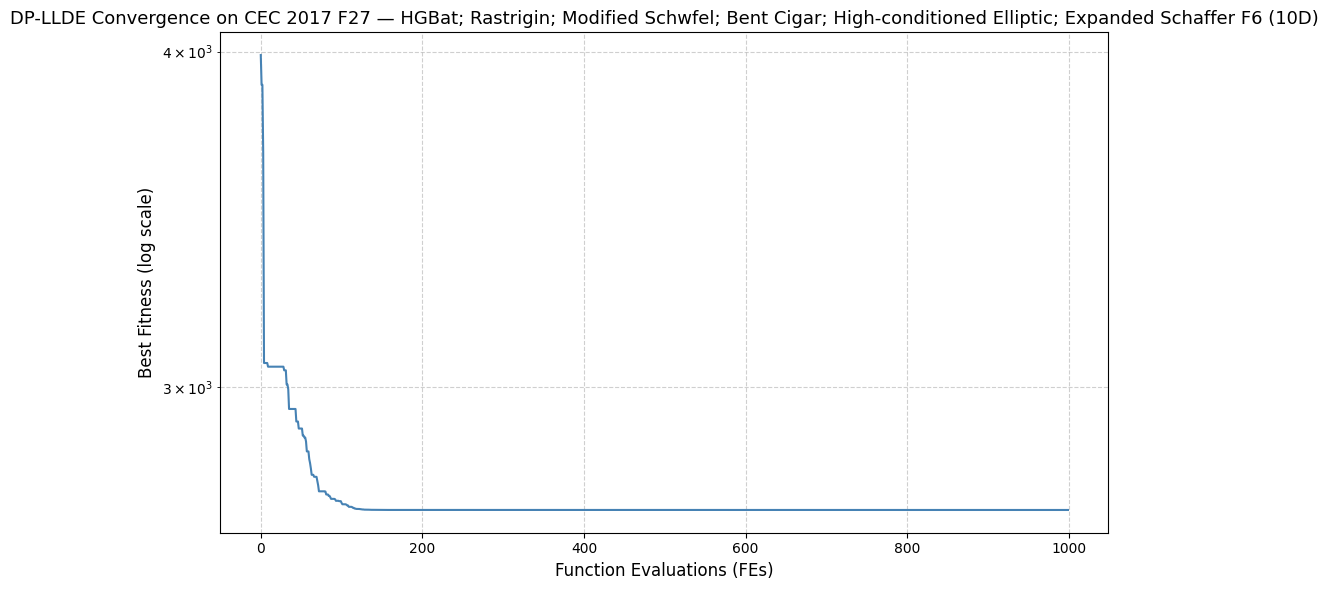

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F27 — HGBat; Rastrigin; Modified Schwfel; Bent Cigar; High-conditioned Elliptic; Expanded Schaffer F6 (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F27.png', dpi=150)
plt.show()

### **F28**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F28 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F282017(ndim=D)
print(f'\nFunction       : F28 — Ackley; Griewank; Discus; Rosenbrock; HappyCat; Expanded Schaffer F6 ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F28 — Single Run
opfunu CEC 2017 loaded!

Function       : F28 — Ackley; Griewank; Discus; Rosenbrock; HappyCat; Expanded Schaffer F6 (10D)
Bounds         : [-100.  100.]
Global optimum : 2800.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.563194e+10
Generation   10: Best = 3.938613e+05  FES =   1100  μ_F = 0.570  μ_CR = 0.348
Generation   20: Best = 2.774439e+05  FES =   2100  μ_F = 0.604  μ_CR = 0.338
Generation   30: Best = 2.774439e+05  FES =   3100  μ_F = 0.651  μ_CR = 0.324
Generation   40: Best = 5.049940e+04  FES =   4100  μ_F = 0.743  μ_CR = 0.300
Generation   50: Best = 1.478816e+04  FES =   5100  μ_F = 0.770  μ_CR = 0.286
Generation   60: Best = 1.478816e+04  FES =   6100  μ_F = 0.769  μ_CR = 0.232
Generation   70: Best = 1.478816e+04  FES =   7100  μ_F = 0.790  μ_CR = 0.190
Generation   80: Best = 1.478816e+04  FES =   8100  μ_F = 0.813  μ_CR = 0.160
Generation   90: Best = 1.478816e+04  FES =   9100  μ_F

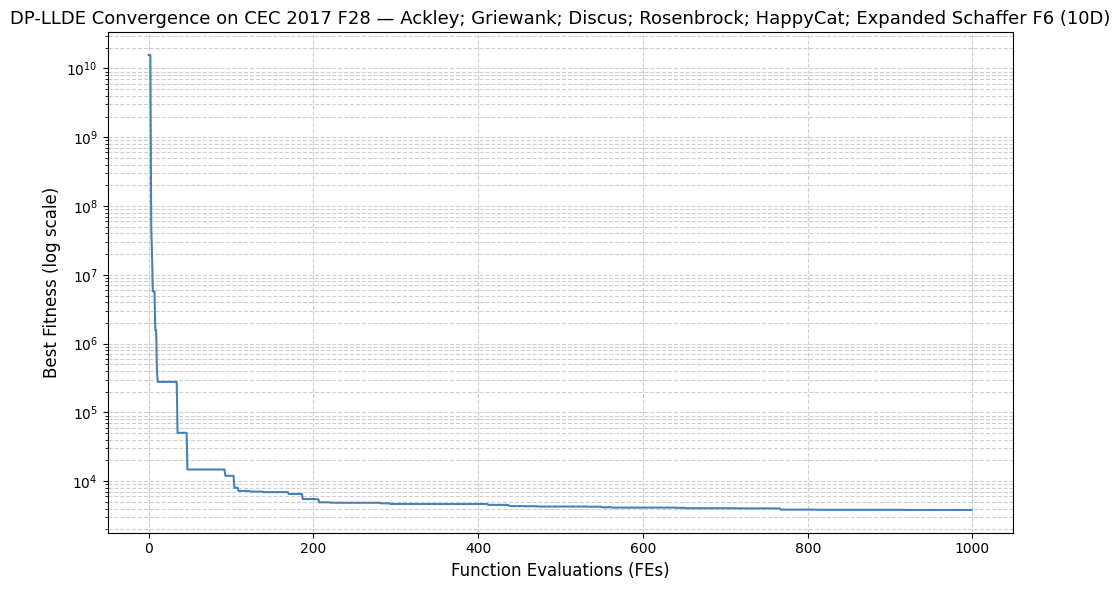

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F28 — Ackley; Griewank; Discus; Rosenbrock; HappyCat; Expanded Schaffer F6 (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F28.png', dpi=150)
plt.show()

### **F29 (opfunu error)**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F29 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F292017(ndim=D)
print(f'\nFunction       : F29 — F15; F16; F17 ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

# Note: F17 returns nan due to numerical overflow in opfunu's Katsuura component.
# A finite penalty (1e18) is applied to nan evaluations to allow the algorithm to proceed.
def safe_eval(x):
    val = func_obj.evaluate(x)
    return val if np.isfinite(val) else 1e18

opt = DPLLDE(
    objective_func=safe_eval,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F29 — Single Run
opfunu CEC 2017 loaded!

Function       : F29 — F15; F16; F17 (10D)
Bounds         : [-100.  100.]
Global optimum : 2900.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.000000e+18
Generation   10: Best = 1.000000e+18  FES =   1100  μ_F = 0.594  μ_CR = 0.354
Generation   20: Best = 1.000000e+18  FES =   2100  μ_F = 0.670  μ_CR = 0.355
Generation   30: Best = 1.000000e+18  FES =   3100  μ_F = 0.730  μ_CR = 0.359
Generation   40: Best = 1.000000e+18  FES =   4100  μ_F = 0.774  μ_CR = 0.353
Generation   50: Best = 1.000000e+18  FES =   5100  μ_F = 0.810  μ_CR = 0.355
Generation   60: Best = 1.000000e+18  FES =   6100  μ_F = 0.831  μ_CR = 0.353
Generation   70: Best = 1.000000e+18  FES =   7100  μ_F = 0.848  μ_CR = 0.358
Generation   80: Best = 1.000000e+18  FES =   8100  μ_F = 0.857  μ_CR = 0.356
Generation   90: Best = 1.000000e+18  FES =   9100  μ_F = 0.871  μ_CR = 0.363
Generation  100: Best = 1.000000

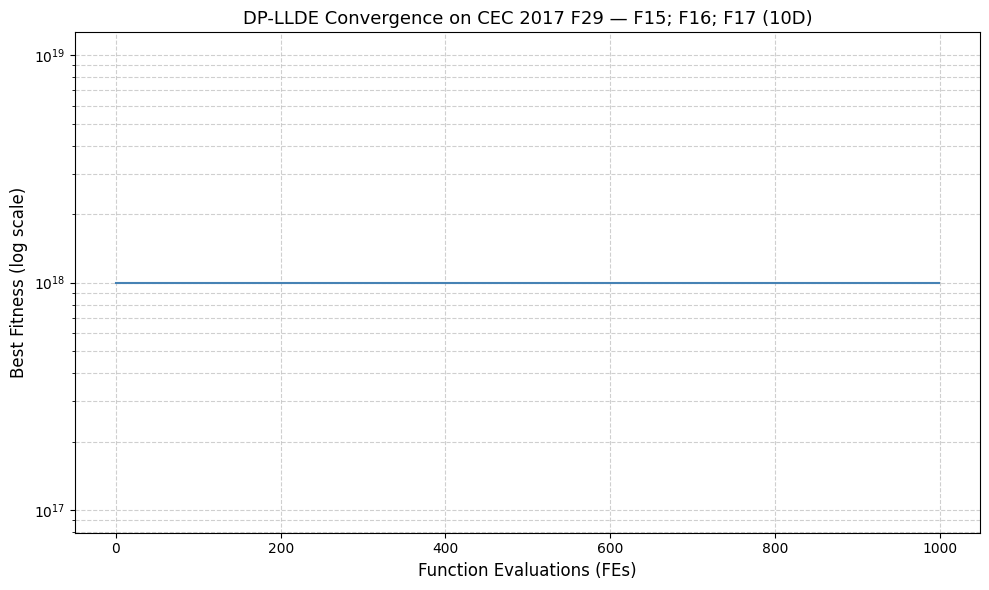

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F29 — F15; F16; F17 (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F29.png', dpi=150)
plt.show()

### **F30 (not available in opfunu 1.0.1 — skipped)**

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F30 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F302017(ndim=D)
print(f'\nFunction       : F30 — F15; F18; F19 ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F30 — Single Run
opfunu CEC 2017 loaded!


AttributeError: module 'opfunu.cec_based.cec2017' has no attribute 'F302017'

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.xlabel('Function Evaluations (FEs)', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('DP-LLDE Convergence on CEC 2017 F30 — F15; F18; F19 (10D)', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('convergence_F30.png', dpi=150)
plt.show()

## **Version Check**

---



In [ ]:
!pip install opfunu numpy scipy --quiet
import opfunu
print(opfunu.__version__)

1.0.1


In [ ]:
import opfunu

In [ ]:
!pip install --upgrade opfunu